# A Bayesian Network for Modeling and Explaining Diabaese Prediction


## Abstract
This project presents a Bayesian Network designed to model and explain the prediction of diabetes based on various health and lifestyle factors. The network incorporates variables such as age, body mass index (BMI), physical activity, family history, and blood glucose levels to provide a probabilistic framework for understanding the relationships between these factors and the likelihood of developing diabetes. By leveraging the principles of Bayesian inference, the model aims to offer insights into the contributing factors of diabetes, enabling healthcare professionals to make informed decisions regarding prevention and treatment strategies. The network also facilitates explainability by allowing users to visualize how changes in specific variables impact the overall risk of diabetes, thereby enhancing interpretability and trust in the predictions made by the model.

## Dataset Overview
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.


The dataset contains the following attributes:
| Attribute                     | Description                                      |
|-------------------------------|--------------------------------------------------|
| Pregnancies                   | Number of times pregnant                         |
| Glucose                       | Plasma glucose concentration a 2 hours in an oral glucose tolerance test |
| BloodPressure                 | Diastolic blood pressure (mm Hg)                 |
| SkinThickness                 | Triceps skin fold thickness (mm)                 |
| Insulin                       | 2-Hour serum insulin (mu U/ml)                   |
| BMI                           | Body mass index (weight in kg/(height in m)^2)
| DiabetesPedigreeFunction      | Diabetes pedigree function                        |
| Age                           | Age (years)                                      |
| Outcome                       | Class variable (0 or 1) indicating if the patient has diabetes (1) or not (0) |
The dataset consists of 768 instances, with 500 instances labeled as non-diabetic (0) and 268 instances labeled as diabetic (1). The features include both continuous and categorical variables, which will be used to construct the Bayesian Network for predicting diabetes.


## Importing Libraries 

In [55]:
import pgmpy as pg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator,HillClimbSearch,TreeSearch,BDeu,K2,BIC,BDs,AIC
from pgmpy.independencies import IndependenceAssertion
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
import networkx as nx


## EDA

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process. It helps us to better understand the given data, so that we can make sense out of it. If EDA is not done properly, it can hamper the further steps in the machine learning model building process. On the other hand, if done well, it may improve the efficacy of everything we do next. In order to perform EDA, we need to follow a systematic approach that involves several techniques. The following are some of the key steps involved in EDA:

1. Data Sourcing: This is the very first step of EDA, where we access data and load it into our system.

2. Data Cleaning: Once we have the data, we need to clean it by removing any inconsistencies, missing values, or outliers.

3. Analysing Dataset Characteristics: This step involves understanding the structure and properties of the dataset, such as data types, distributions, and relationships between variables.
   
In here We Analyse the dataset before and after cleaning it. So we can have a better understanding of cleaning process effects on the dataset.

On Data Analysis we do the following steps: 

1. statistical summary of the dataset
2. plotting distributions of features
3. checking for missing values
4. checking for zero values in features where it is not possible
5. scatter plot of each feature vs Outcome
6. pair plot of features
7. heatmap of correlation matrix

## Data Sourcing

In [56]:
# merging two csv files into one
df = pd.read_csv('data/diabetes.csv',sep=',')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Analysing Dataset Characteristics before Cleaning

### statistics lookup of each feature

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

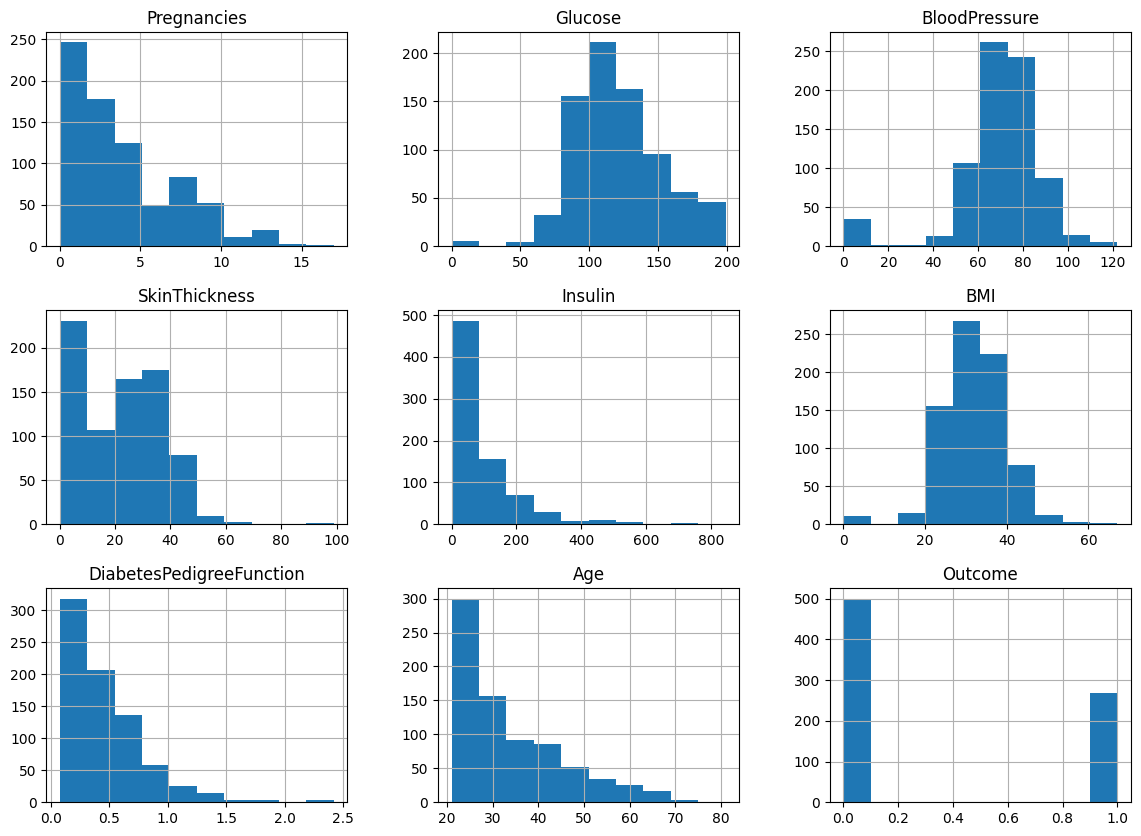

In [57]:
df.hist(figsize=(14,10))

In [58]:
statistic = df.describe().round(2)
statistic.loc['range'] = statistic.loc['max'] - statistic.loc['min']
statistic.loc['variance'] = df.var().round(2)
statistic


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00
range,17.00,199.00,122.00,99.00,846.00,67.10,2.34,60.00,1.00
variance,11.35,1022.25,374.65,254.47,13281.18,62.16,0.11,138.30,0.23


### Correlation Matrix

In [59]:

## Corelleation Matrix
correlation_matrix = df.corr()
correlation_matrix


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


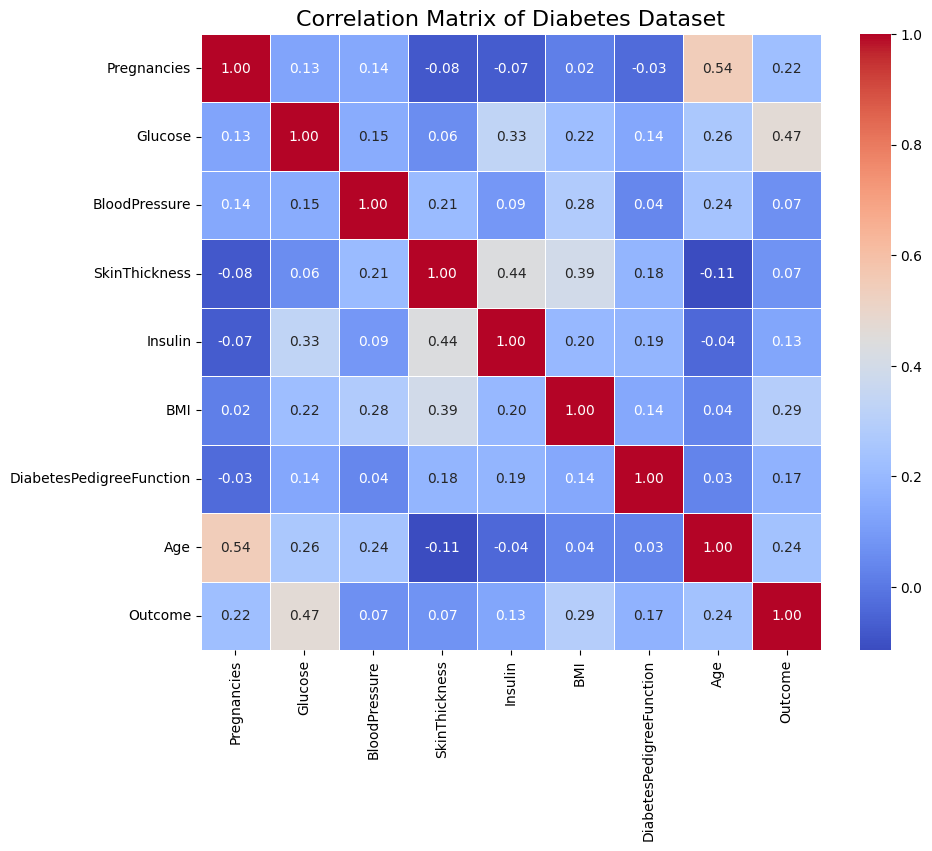

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidth=.5)
plt.title('Correlation Matrix of Diabetes Dataset', fontsize=16)
plt.savefig('correlation_matrix.png')
plt.show()

### Box Plot of each feature 

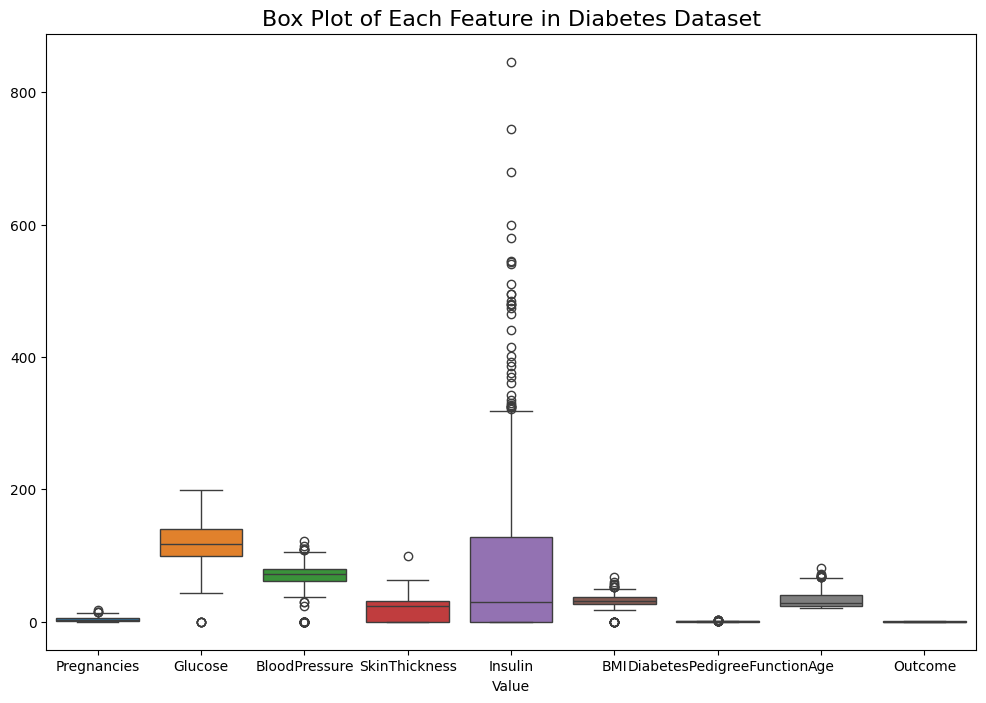

In [61]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df)
plt.title('Box Plot of Each Feature in Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_features.png')
plt.show()

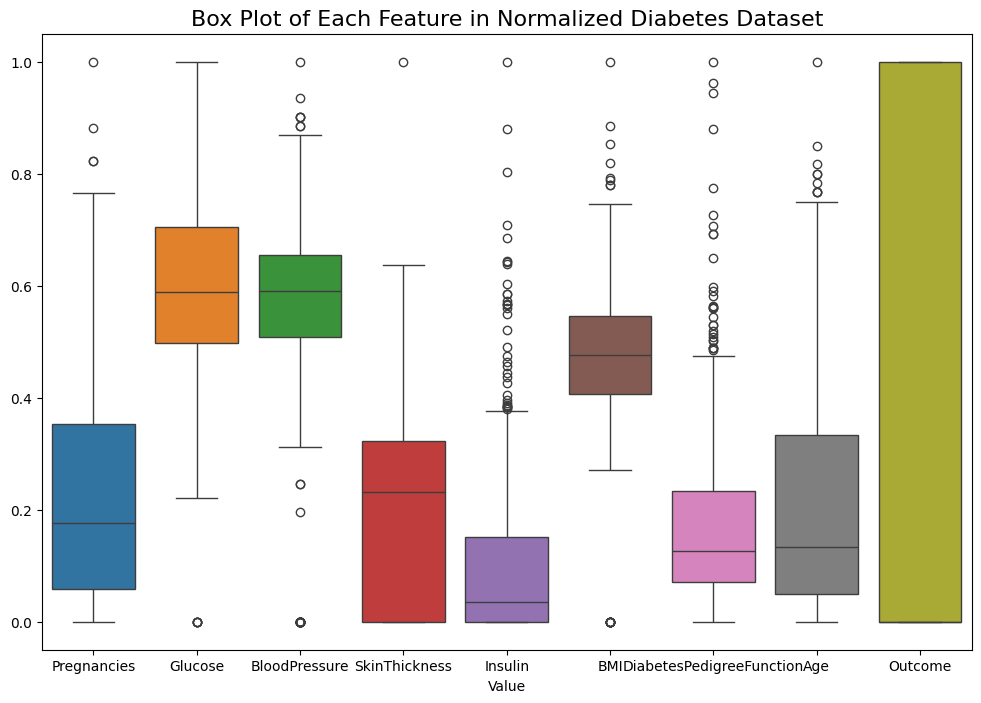

In [62]:
# normalize and check box plot again
scaler = MinMaxScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
plt.figure(figsize=(12, 8))
sns.boxplot(data=normalized_data)
plt.title('Box Plot of Each Feature in Normalized Diabetes Dataset', fontsize=16)
plt.xlabel('Value')
plt.savefig('box_plot_normalized_features.png')
plt.show()

### Scatter Plot of each feature vs Outcome

<Figure size 640x480 with 0 Axes>

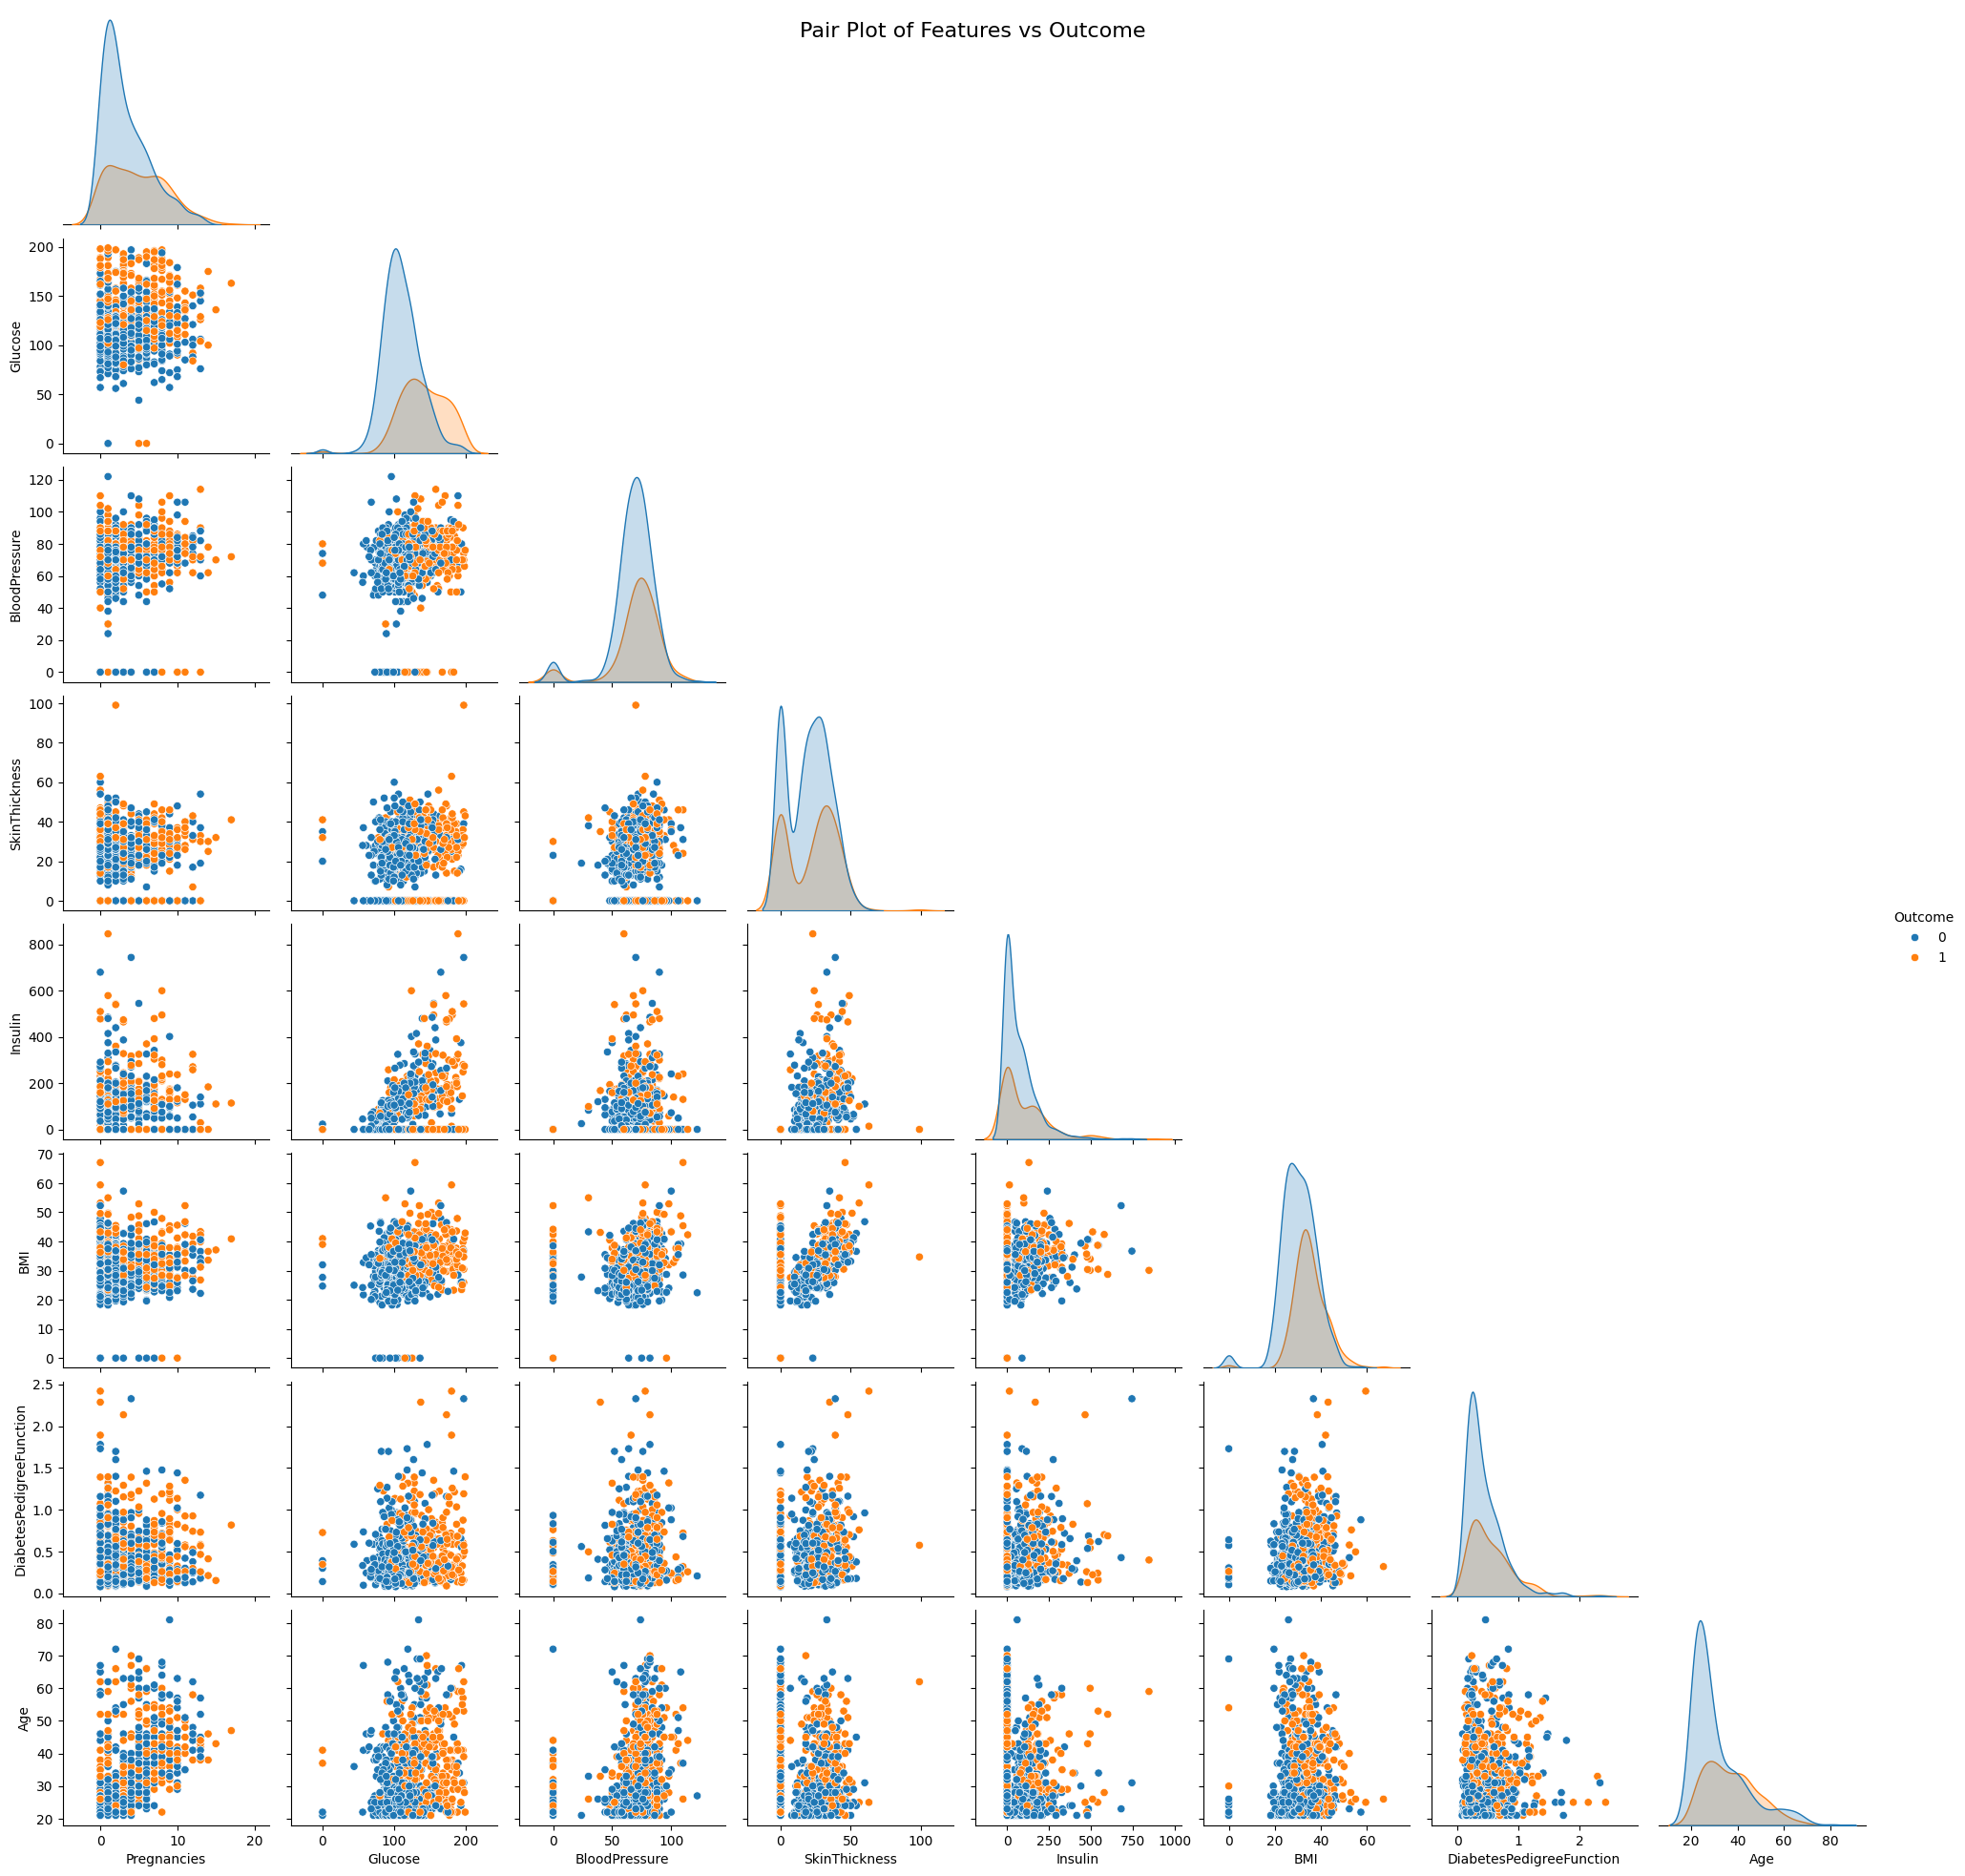

In [63]:
plt.figure()
sns.pairplot(
    df,
    vars=[df.columns[i] for i in range(len(df.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_features_vs_outcome.png')
plt.show()


### Pie Chart of Outcome feature

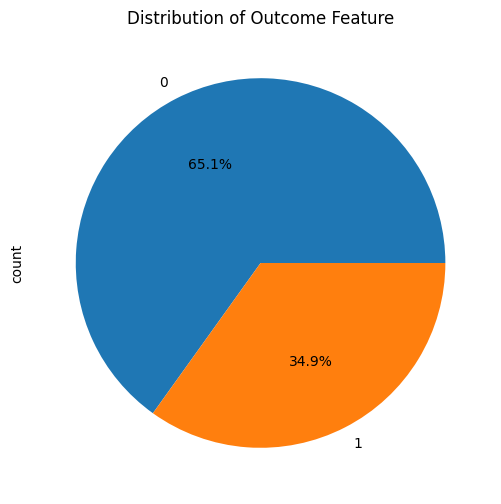

In [64]:
df["Outcome"].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Distribution of Outcome Feature')
plt.savefig('outcome_distribution_pie_chart.png')
plt.show()

### Check for missing Values

In [65]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check for zero values in features where it is not possible

In [66]:
zero_value_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI','Age']
zero_value_counts = {col: (df[col] == 0).sum() for col in zero_value_columns}
zero_value_counts

{'Glucose': 5, 'BloodPressure': 35, 'SkinThickness': 227, 'BMI': 11, 'Age': 0}

## Preprocessing

In this section, we will preprocess the dataset to prepare it for building the Bayesian Network model. The preprocessing steps include handling missing values, and discretizing continuous variables into numeric bins.

for handling missing values we can use three methods:
1. Remove rows with missing values
2. Remove column with most missing values and remove rows with missing values in other columns
3. Impute missing values with mean/median/mode
4. Use advanced imputation techniques like KNN imputation or regression imputation

if we use firsy method we will lose a lot of data, so
we will use Impute missing values with mean and  KNN imputation for handling missing values. After that we will compare the results of each method.

for handling discretization we can use five methods:
1. Equal Width Binning
2. Quantile Binning
3. K-Means Binning
4. round Values to nearest integer

we will user K-Means and Quantile  Binning for discretization of continuous variables. After that we will compare the results of each method.

Challenges:
1. after handling missing values with mean imputaion or knn imputaion we will create new continuous columns, so we need to threat them diffrently in discretization step. We have two options here:
   - we can discretize them along with other continuous columns with same methods.
   - we can discretize them separately using round values to nearest integer method.
we will use the second option for discretization of imputed columns.

At the end of this section we will have four different preprocessed datasets to compare the results of each method.

### Handling Missing Values

#### Drop Column with most missing values and remove rows with missing values in other columns

In [67]:
df_dropped = df.copy()
df_dropped = df_dropped.drop('SkinThickness',axis=1)
zero_value_columns_dropped = ['Glucose', 'BloodPressure', 'BMI','Age']
for col in zero_value_columns_dropped:
    df_dropped = df_dropped[df_dropped[col] != 0]
display(df_dropped.isnull().sum())
df_dropped

Pregnancies                 0
Glucose                     0
BloodPressure               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,0,33.6,0.627,50,1
1,1,85,66,0,26.6,0.351,31,0
2,8,183,64,0,23.3,0.672,32,1
3,1,89,66,94,28.1,0.167,21,0
4,0,137,40,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,10,101,76,180,32.9,0.171,63,0
764,2,122,70,0,36.8,0.340,27,0
765,5,121,72,112,26.2,0.245,30,0
766,1,126,60,0,30.1,0.349,47,1


#### Imputing missing values with mean

In [68]:
df_mean_imputed = df.copy()
for col in zero_value_columns:
    mean_value = df_mean_imputed[col].replace(0, np.nan).mean()
    df_mean_imputed[col] = df_mean_imputed[col].replace(0, mean_value)
display(df_mean_imputed[zero_value_columns].isnull().sum())
df_mean_imputed

Glucose          0
BloodPressure    0
SkinThickness    0
BMI              0
Age              0
dtype: int64

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,0,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,0,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,0,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,0,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,0,30.1,0.349,47,1


#### Imputing missing values with KNN imputation

In [69]:
df_knn_imputed = df.copy()
df_knn_imputed[zero_value_columns] = df_knn_imputed[zero_value_columns].replace(0, np.nan)
imputer = KNNImputer(n_neighbors=10)
df_knn_imputed[zero_value_columns] = imputer.fit_transform(df_knn_imputed[zero_value_columns])
df_knn_imputed[zero_value_columns].isnull().sum()
df_knn_imputed

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,0,33.6,0.627,50.0,1
1,1,85.0,66.0,29.0,0,26.6,0.351,31.0,0
2,8,183.0,64.0,26.8,0,23.3,0.672,32.0,1
3,1,89.0,66.0,23.0,94,28.1,0.167,21.0,0
4,0,137.0,40.0,35.0,168,43.1,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180,32.9,0.171,63.0,0
764,2,122.0,70.0,27.0,0,36.8,0.340,27.0,0
765,5,121.0,72.0,23.0,112,26.2,0.245,30.0,0
766,1,126.0,60.0,33.6,0,30.1,0.349,47.0,1


### Show correlation matrix after handling missing values

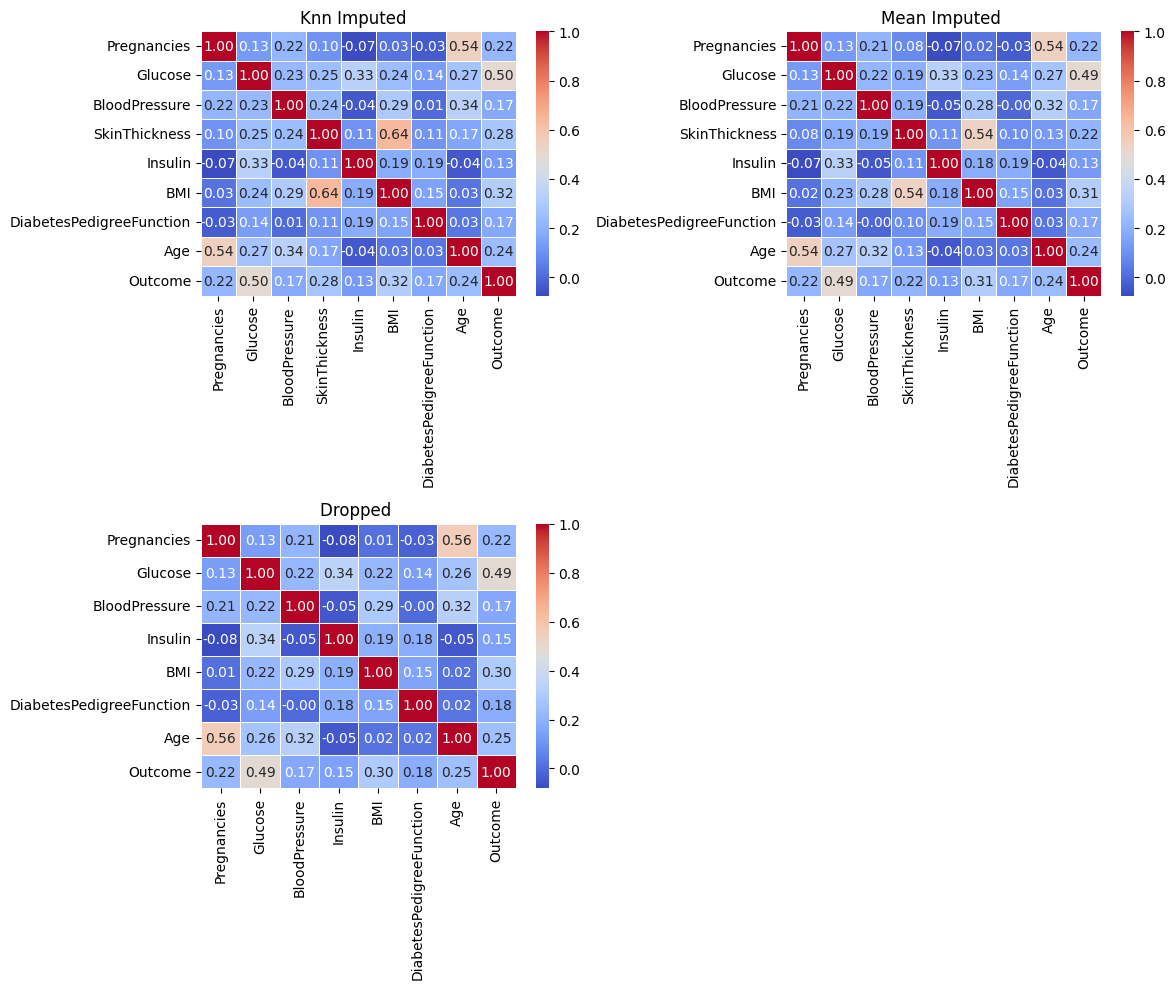

In [70]:
correlation_knn = df_knn_imputed.corr()
correlation_mean = df_mean_imputed.corr()
correlation_dropped = df_dropped.corr()
# plot all four correlation matrices
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_knn, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.5)
plt.title('Knn Imputed  ', fontsize=12)
plt.subplot(2, 2, 2)
sns.heatmap(correlation_mean , annot=True, cmap='coolwarm', fmt
=".2f", linewidth=.5)
plt.title('Mean Imputed ', fontsize=12)
plt.subplot(2, 2, 3)
sns.heatmap(correlation_dropped, annot=True, cmap='coolwarm',
    fmt=".2f", linewidth=.5)    
plt.title('Dropped ', fontsize=12)
plt.tight_layout()
plt.savefig('correlation_matrices_imputation.png')
plt.show()

### Palot of features after handling missing values

<Figure size 640x480 with 0 Axes>

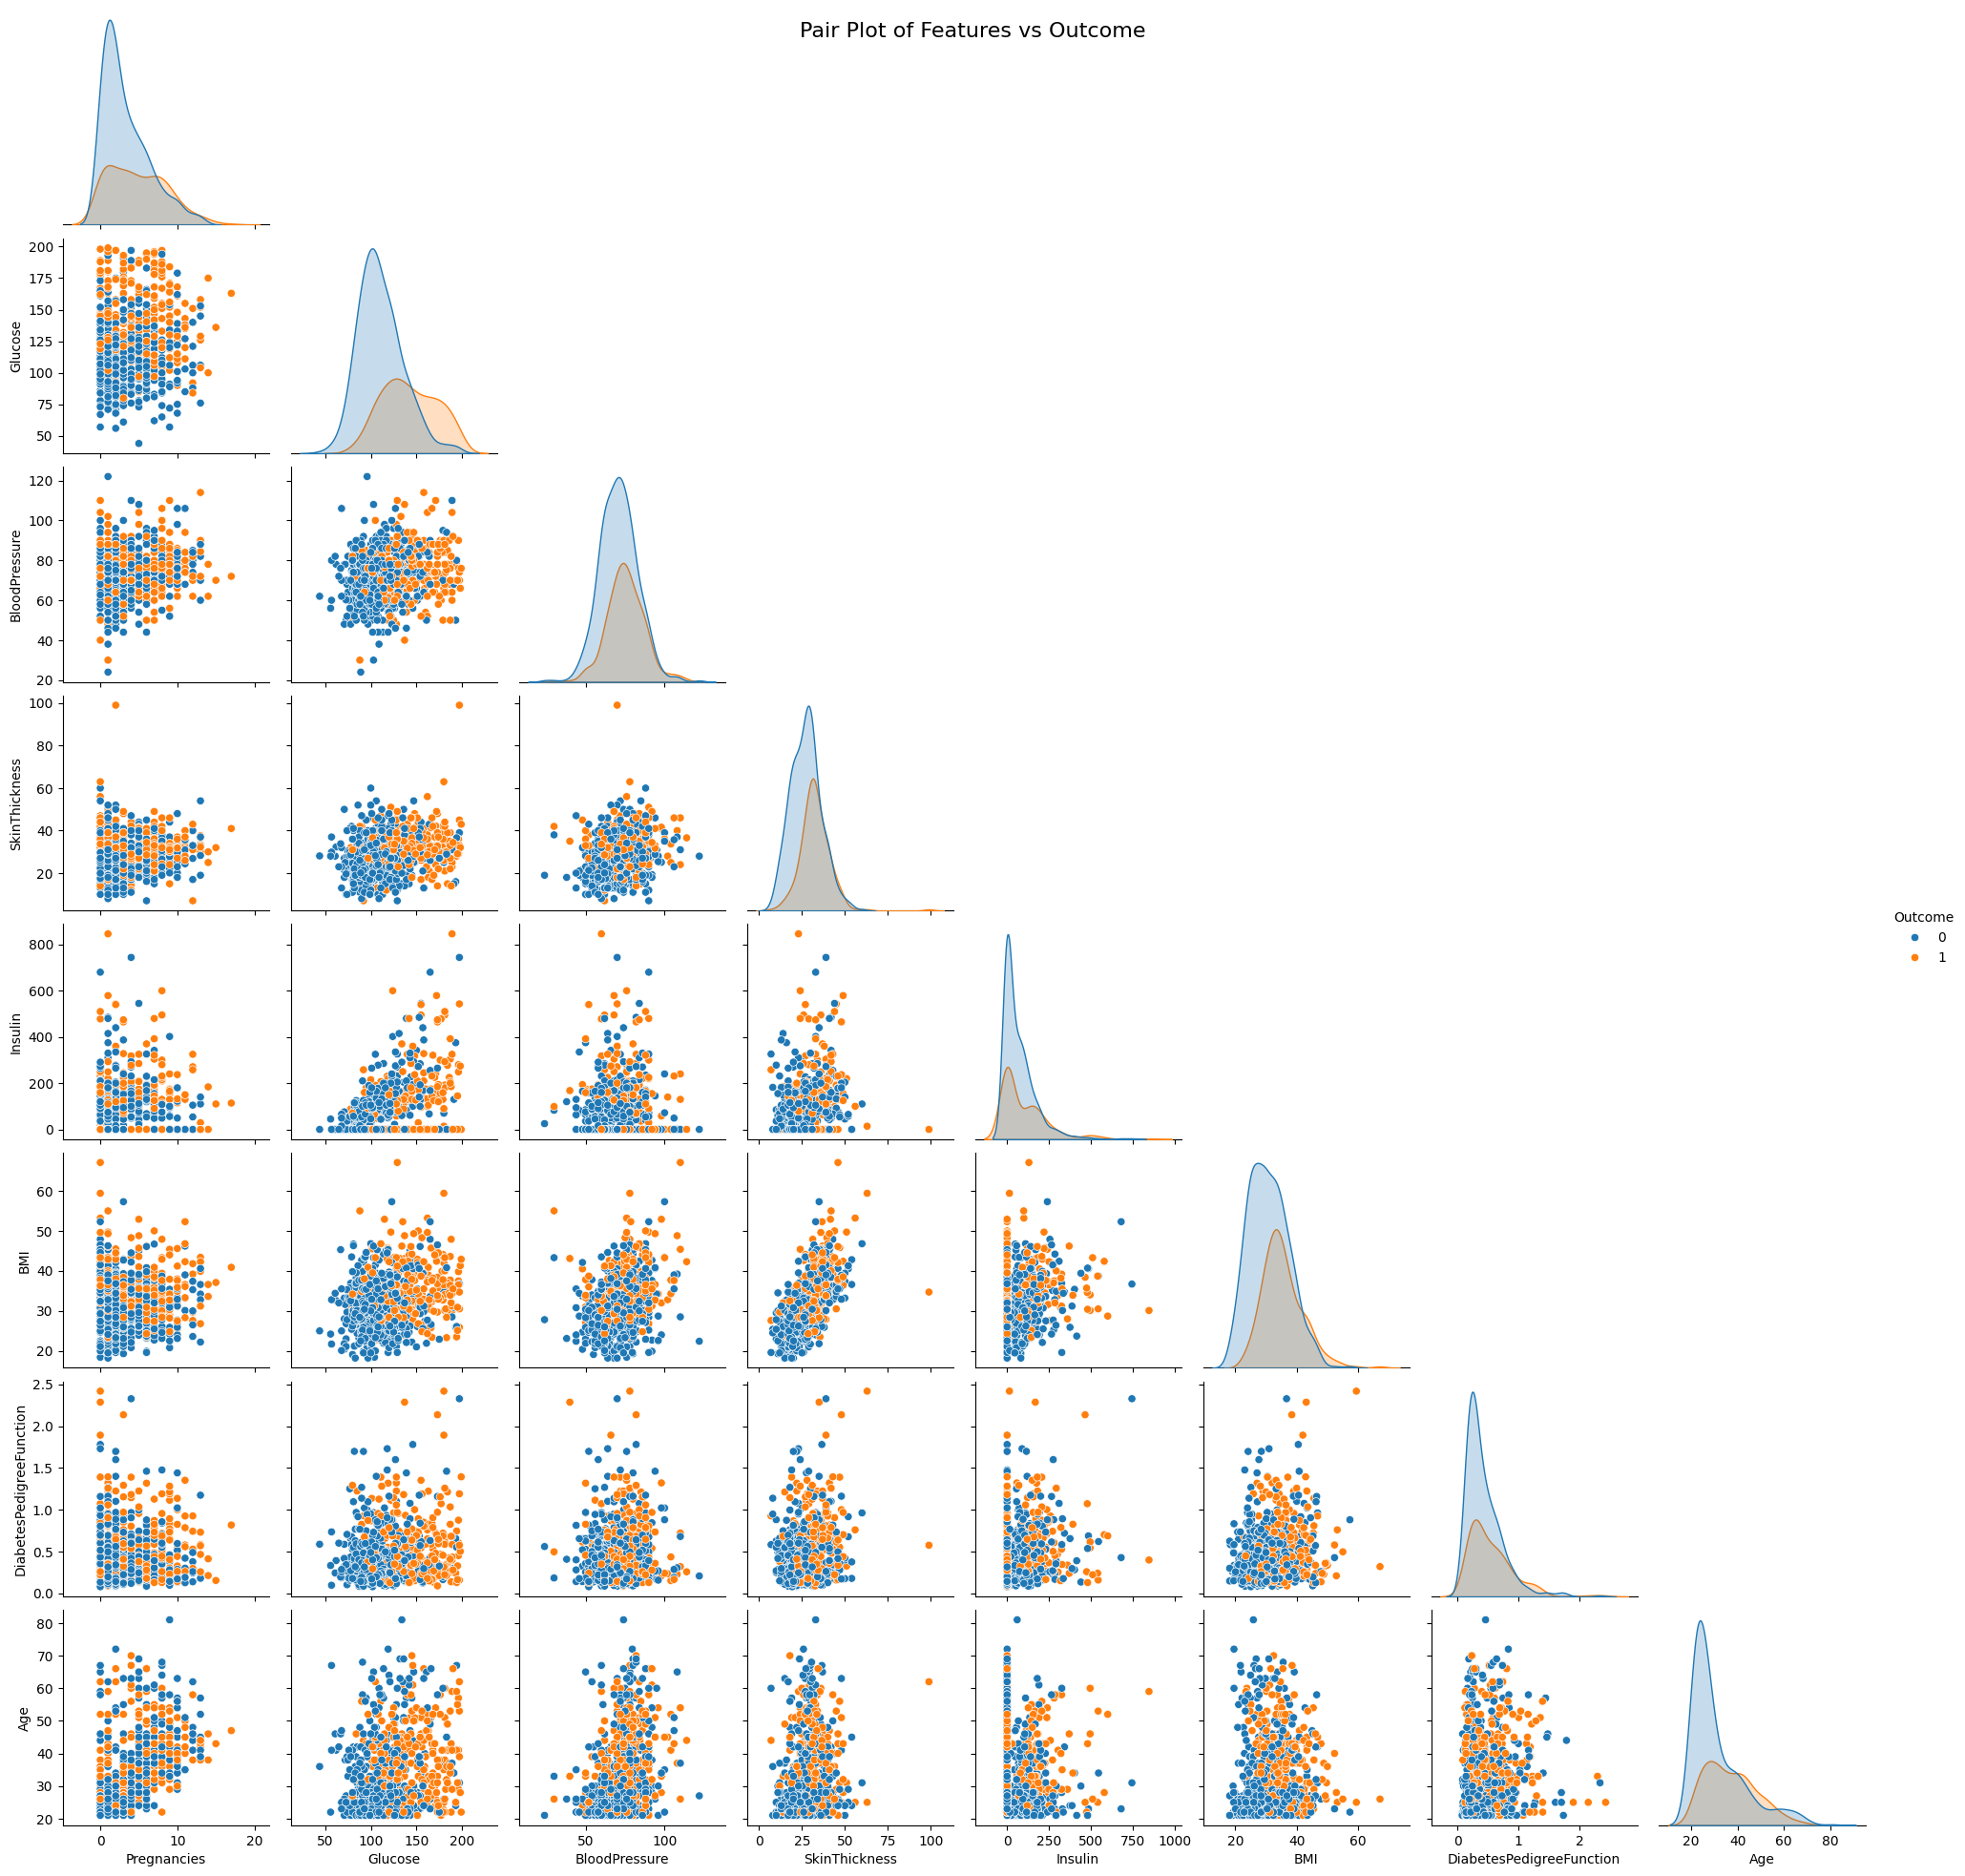

<Figure size 640x480 with 0 Axes>

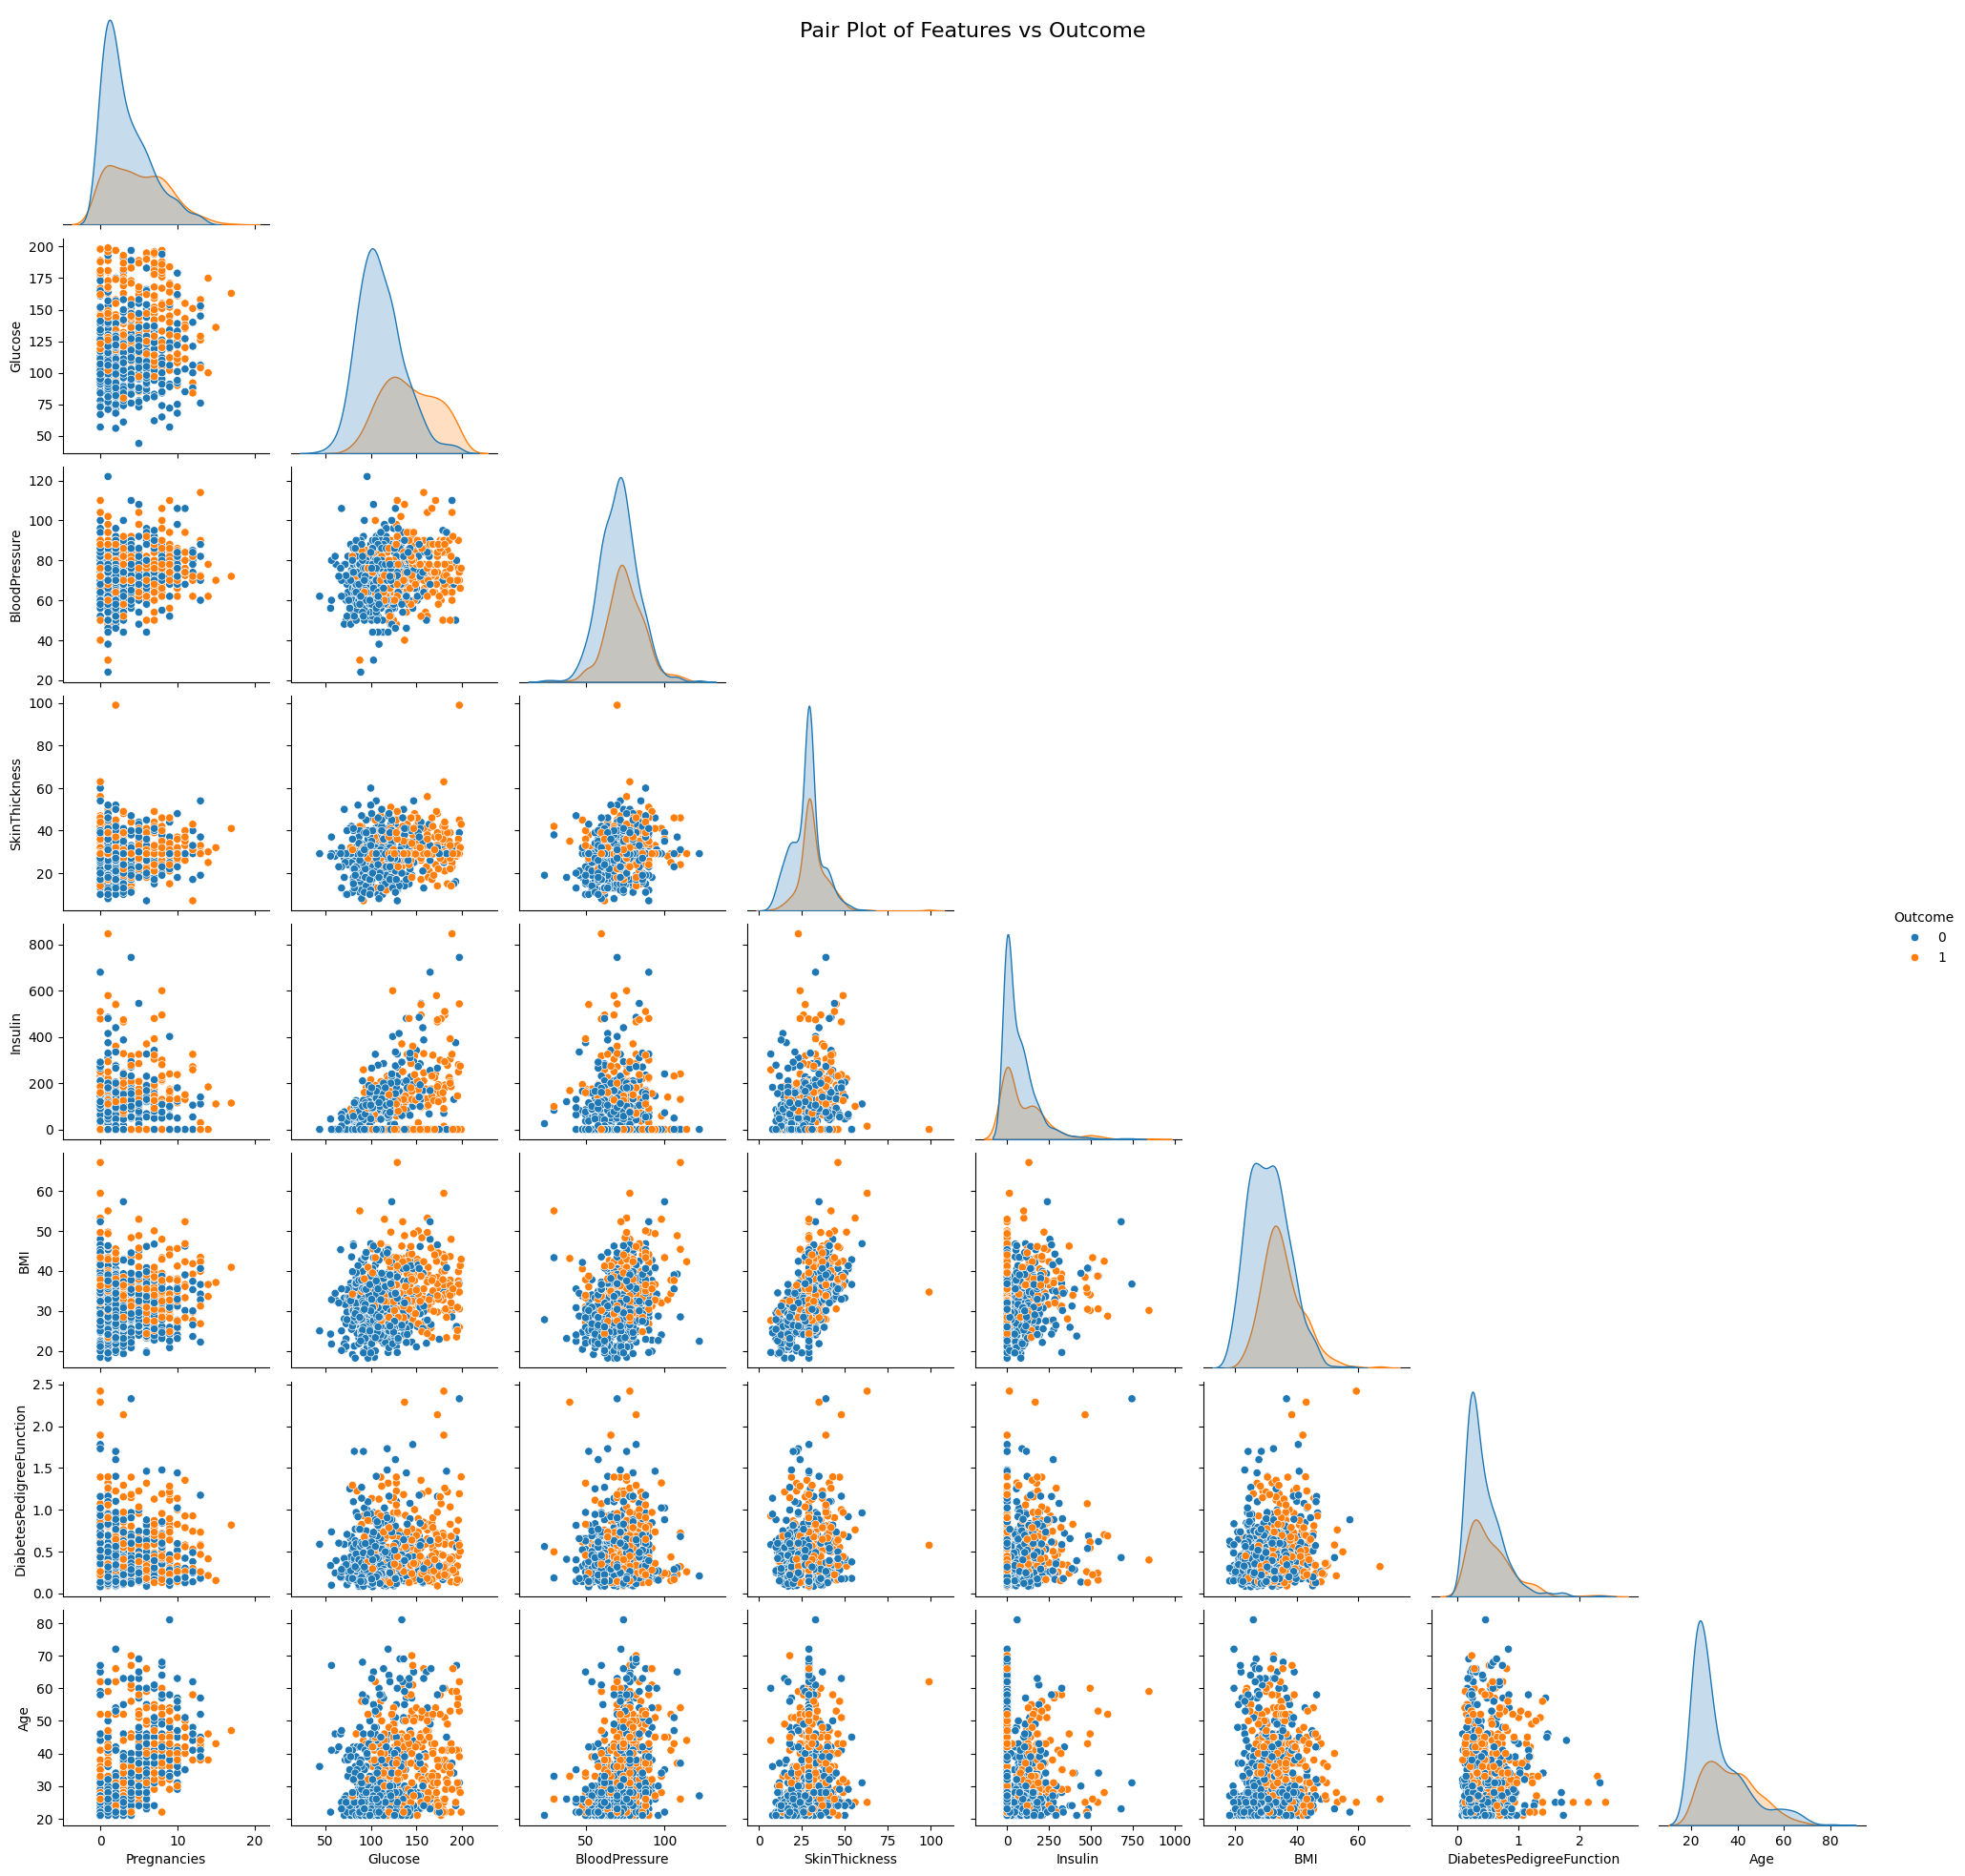

<Figure size 640x480 with 0 Axes>

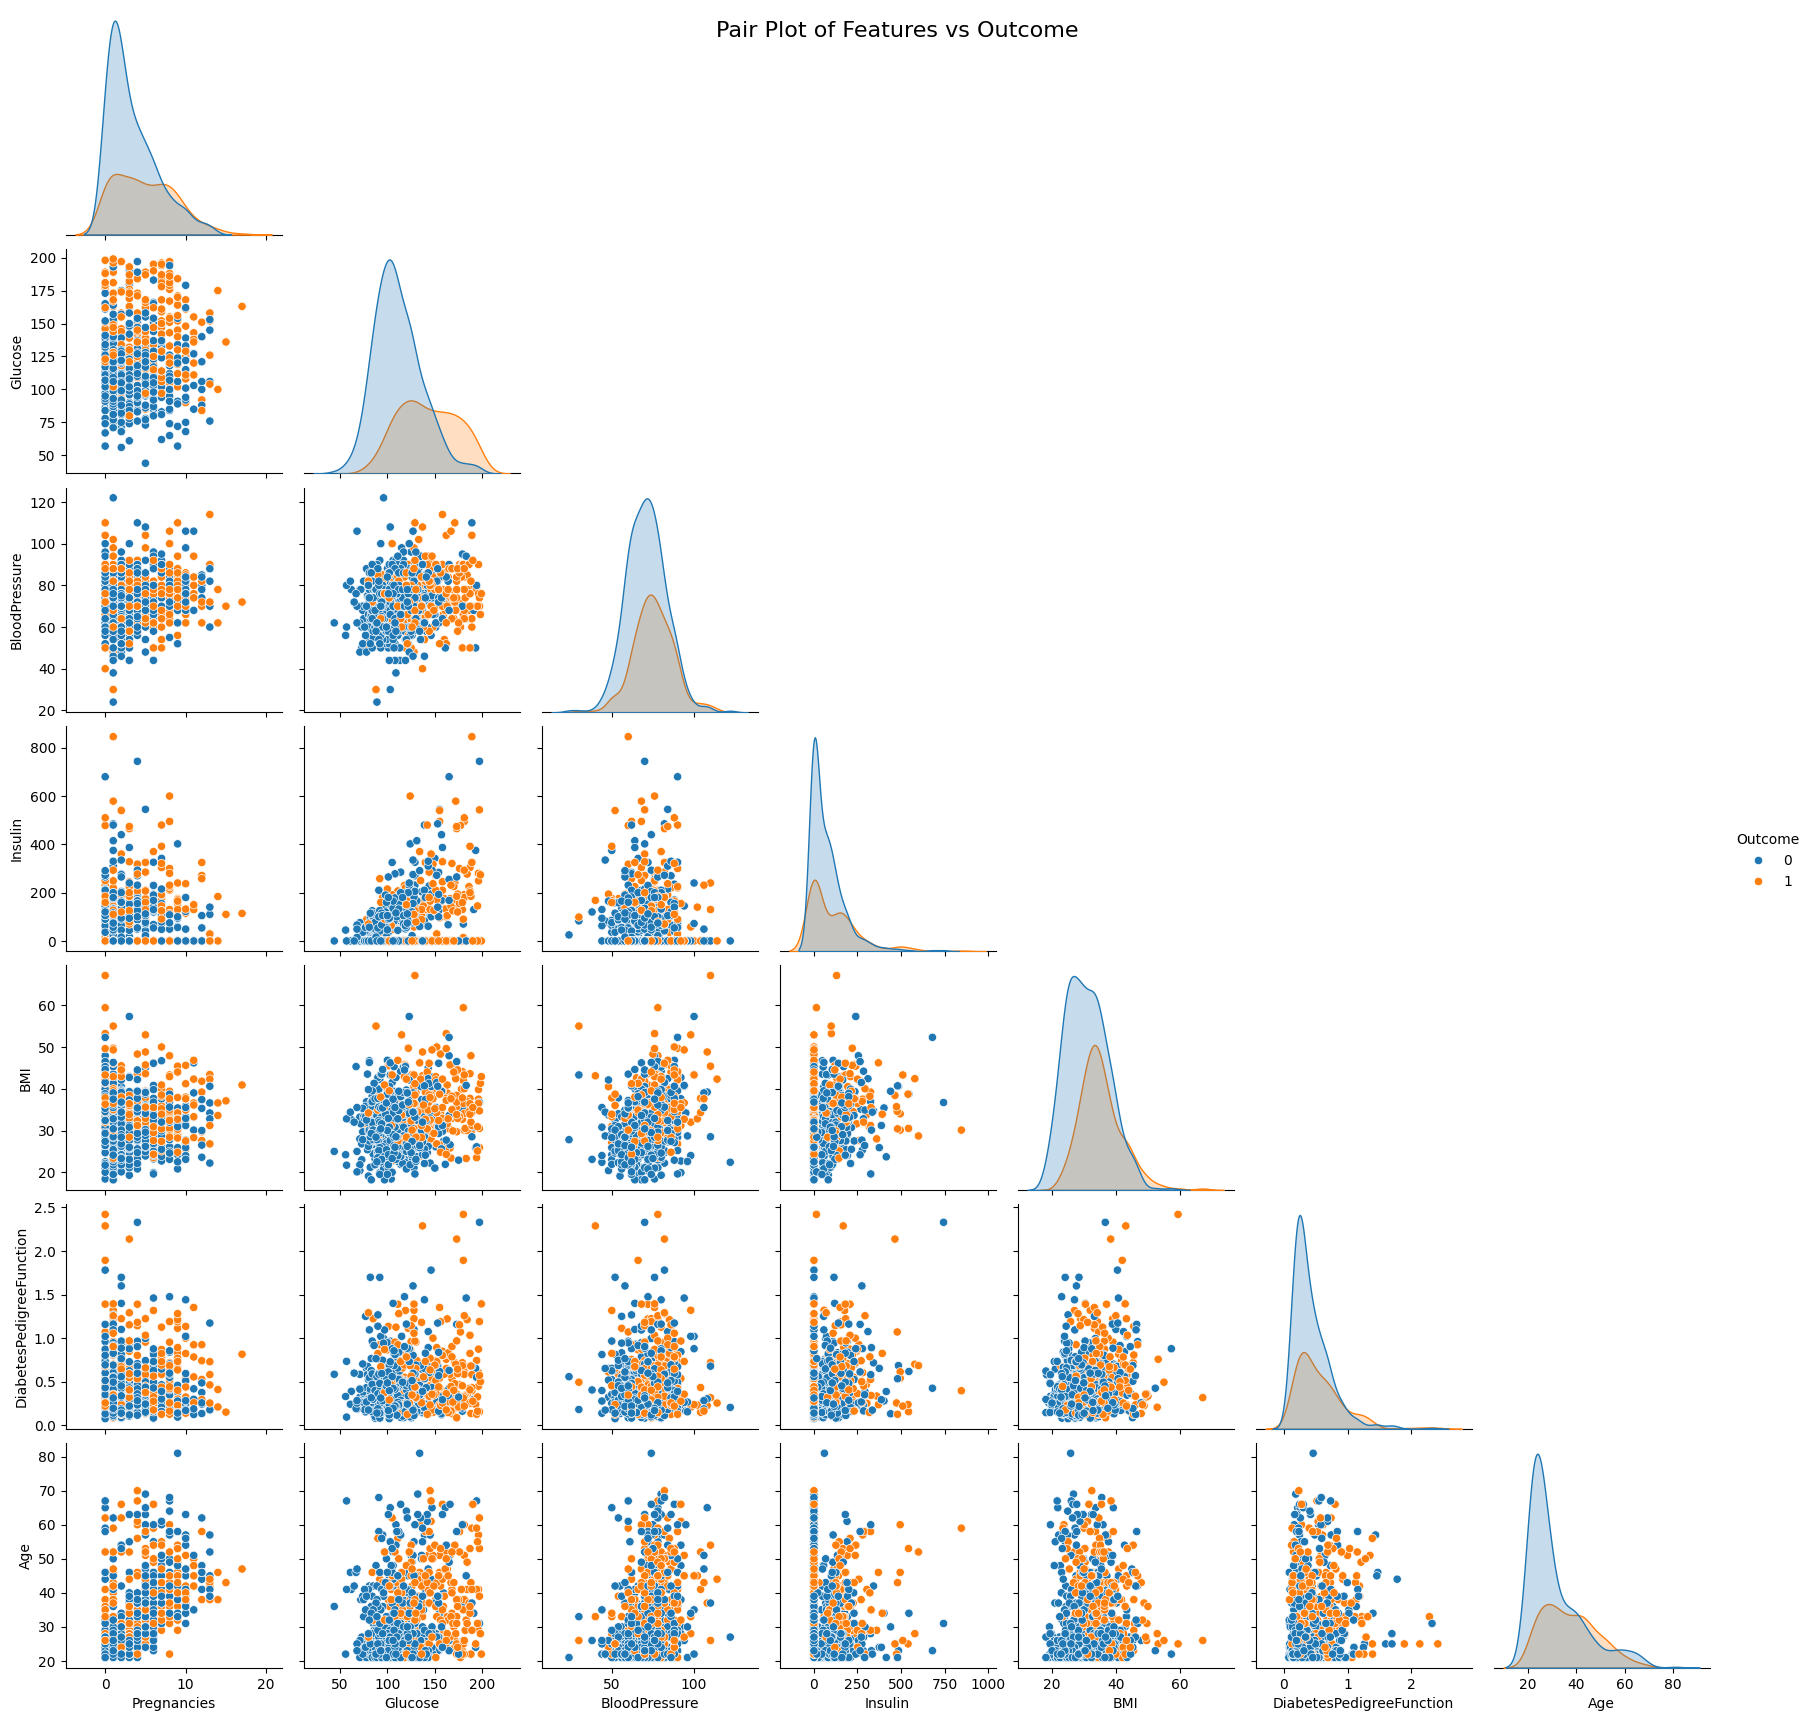

In [71]:
plt.figure()
sns.pairplot(
    df_knn_imputed,
    vars=[  df_knn_imputed.columns[i] for i in range(len(df_knn_imputed.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_knn.png')
plt.figure()
sns.pairplot(
    df_mean_imputed,
    vars=[  df_mean_imputed.columns[i] for i in range(len(df_mean_imputed.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_mean.png')
plt.figure()
sns.pairplot(
    df_dropped,
    vars=[  df_dropped.columns[i] for i in range(len(df_dropped.columns)-1)],
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair Plot of Features vs Outcome', fontsize=16)
plt.savefig('pair_plot_after_handling_missing_values_dropped.png')
plt.show()


### Result
After handling missing values using different methods, we obtained the following correlation matrices for each approach.
We decided to go forward with drop column approach as it provided a good balance between data retention and correlation structure preservation.


### Descretization of Continuous Variables

first we need to check ranges again.

In [72]:
statistic = df_dropped.describe().round(2)
statistic

,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.00,724.00,724.00,724.00,724.00,724.00,724.00,724.00
mean,3.87,121.88,72.40,84.49,32.47,0.47,33.35,0.34
std,3.36,30.75,12.38,117.02,6.89,0.33,11.77,0.48
min,0.00,44.00,24.00,0.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,0.00,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,48.00,32.40,0.38,29.00,0.00
75%,6.00,142.00,80.00,130.50,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,846.00,67.10,2.42,81.00,1.00


#### Descretize with quantile Binning

In [73]:
def fd_q(x):
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    if iqr == 0:
        return 2
    bw = 2 * iqr / (len(x) ** (1/3))
    return int(np.ceil((x.max() - x.min()) / bw))

**Note: Due Insuffiecient resources, we need to convert all features to categorical with qcut before fitting the model.**


In [74]:
df_quantile = df_dropped.copy()
optimal_q = {}

for col in df_dropped.columns:
    if col != 'Outcome':
        q = fd_q(df_dropped[col])
        optimal_q[col] = min(max(q, 2), 10)  # keep it reasonable
        
for col in df_quantile.columns:
    if col != 'Outcome':
        if df_quantile[col].nunique() > 10:
            df_quantile[col] = pd.qcut(df_quantile[col], q=optimal_q[col], labels=False, duplicates='drop')     
print("-------- Dropped DataFrame with Quantile Discretization --------")
display(df_quantile)
display(optimal_q)


-------- Dropped DataFrame with Quantile Discretization --------


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,8,4,0,5,7,8,1
1,0,0,2,0,2,4,5,0
2,6,9,2,0,0,7,5,1
3,0,1,2,2,2,1,0,0
4,0,7,0,4,9,9,5,1
...,...,...,...,...,...,...,...,...
763,7,2,6,4,5,1,9,0
764,1,5,3,0,7,4,3,0
765,4,5,4,2,1,2,5,0
766,0,6,1,0,3,4,8,1


{'Pregnancies': 10,
 'Glucose': 10,
 'BloodPressure': 10,
 'Insulin': 10,
 'BMI': 10,
 'DiabetesPedigreeFunction': 10,
 'Age': 10}

##### Descretize with K-Means Binning

In [75]:
df_kmeans = df_dropped.copy()
kmeans = KMeans(n_clusters=10, random_state=42)

for col in df_kmeans.columns:
    if col != 'Outcome':
        if df_kmeans[col].nunique() > 10:
            new_column_mean = kmeans.fit_predict(df_kmeans[[col]])
            df_kmeans[col] = new_column_mean

print("-------- Dropped DataFrame with KMeans Discretization --------")
display(df_kmeans)


-------- Dropped DataFrame with KMeans Discretization --------


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,3,2,8,9,4,1,1
1,0,4,6,8,2,8,9,0
2,1,1,6,8,6,4,9,1
3,0,2,6,7,1,6,2,0
4,5,7,4,6,8,7,9,1
...,...,...,...,...,...,...,...,...
763,3,6,5,6,9,6,5,0
764,7,0,2,8,3,8,0,0
765,9,0,2,3,2,1,0,0
766,0,9,1,8,1,8,1,1


## Analysing Dataset Characteristics After Cleaning

### Correlation Matrix


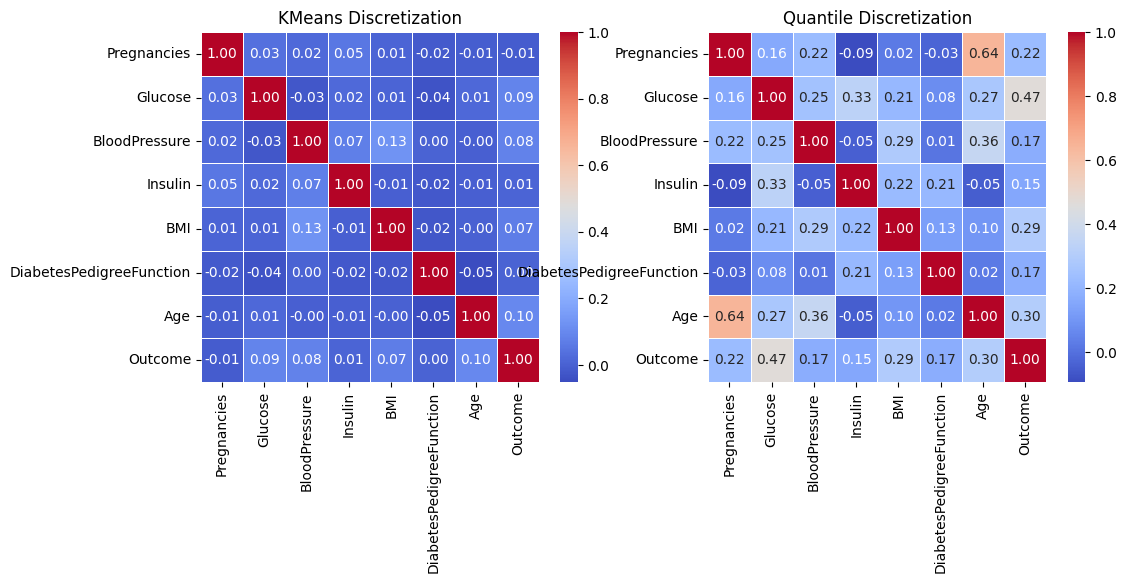

In [76]:
correlation_kmeans = df_kmeans.corr()
correlation_quantile = df_quantile.corr()

# plot all four correlation matrices
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
sns.heatmap(correlation_kmeans, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.5)
plt.title('KMeans Discretization', fontsize=12)
plt.subplot(2, 2, 2)
sns.heatmap(correlation_quantile, annot=True, cmap='coolwarm', fmt
=".2f", linewidth=.5)
plt.title('Quantile Discretization', fontsize=12)

plt.savefig('correlation_matrices_comparison_after_discretization.png')
plt.show()

### Pair plot of each changed feature vs Outcome


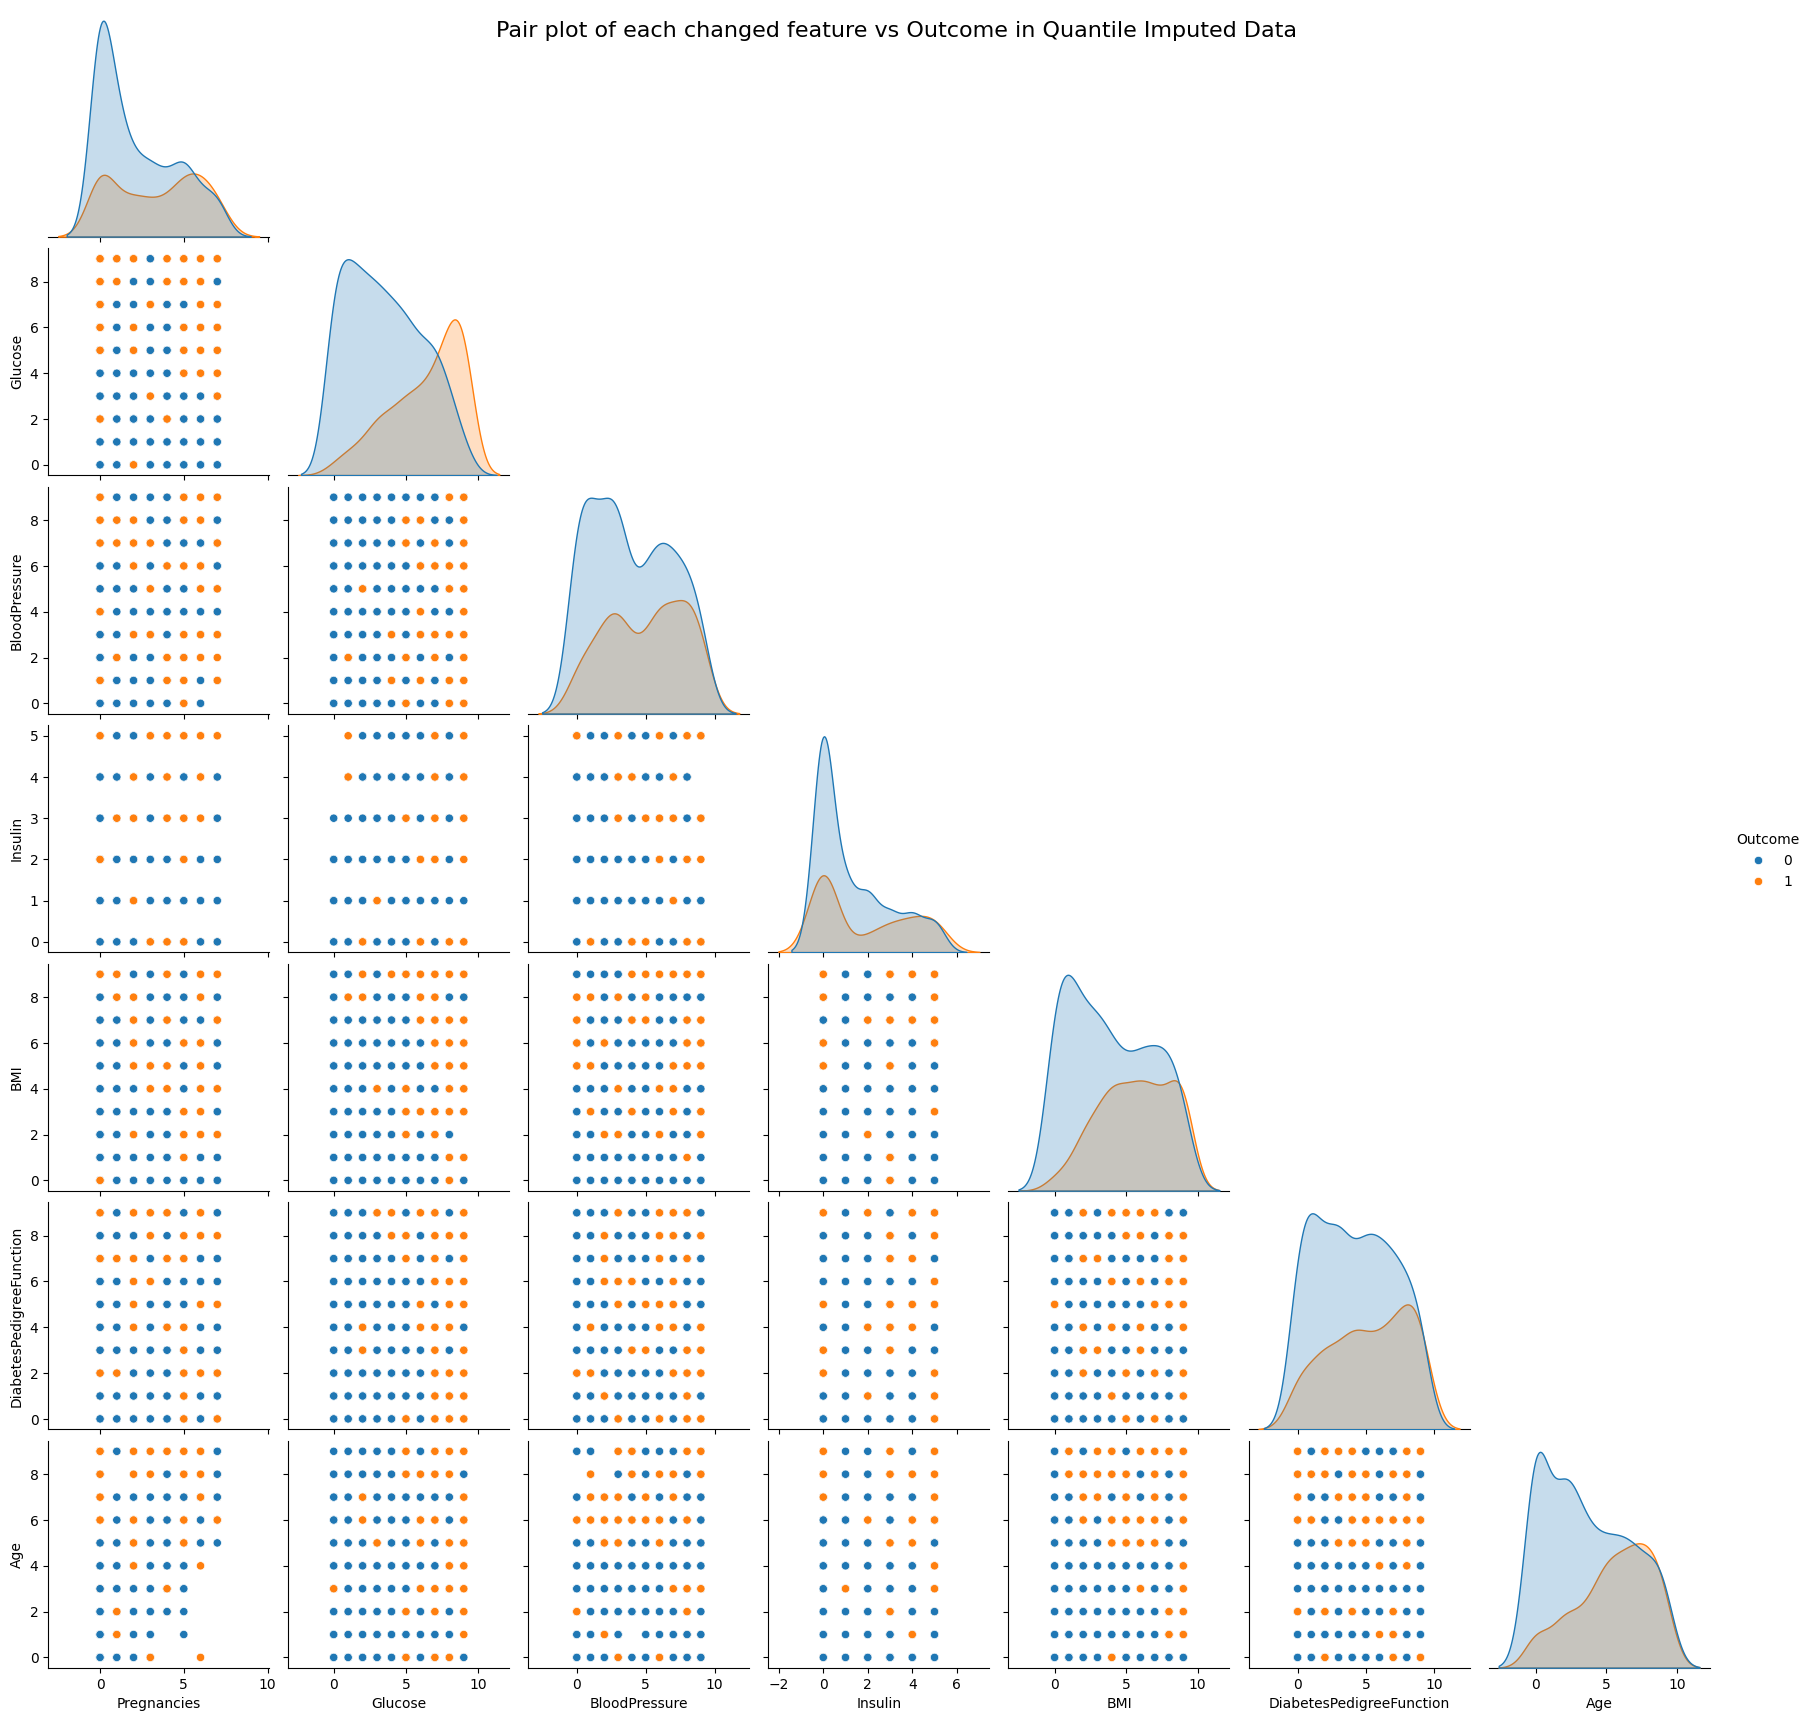

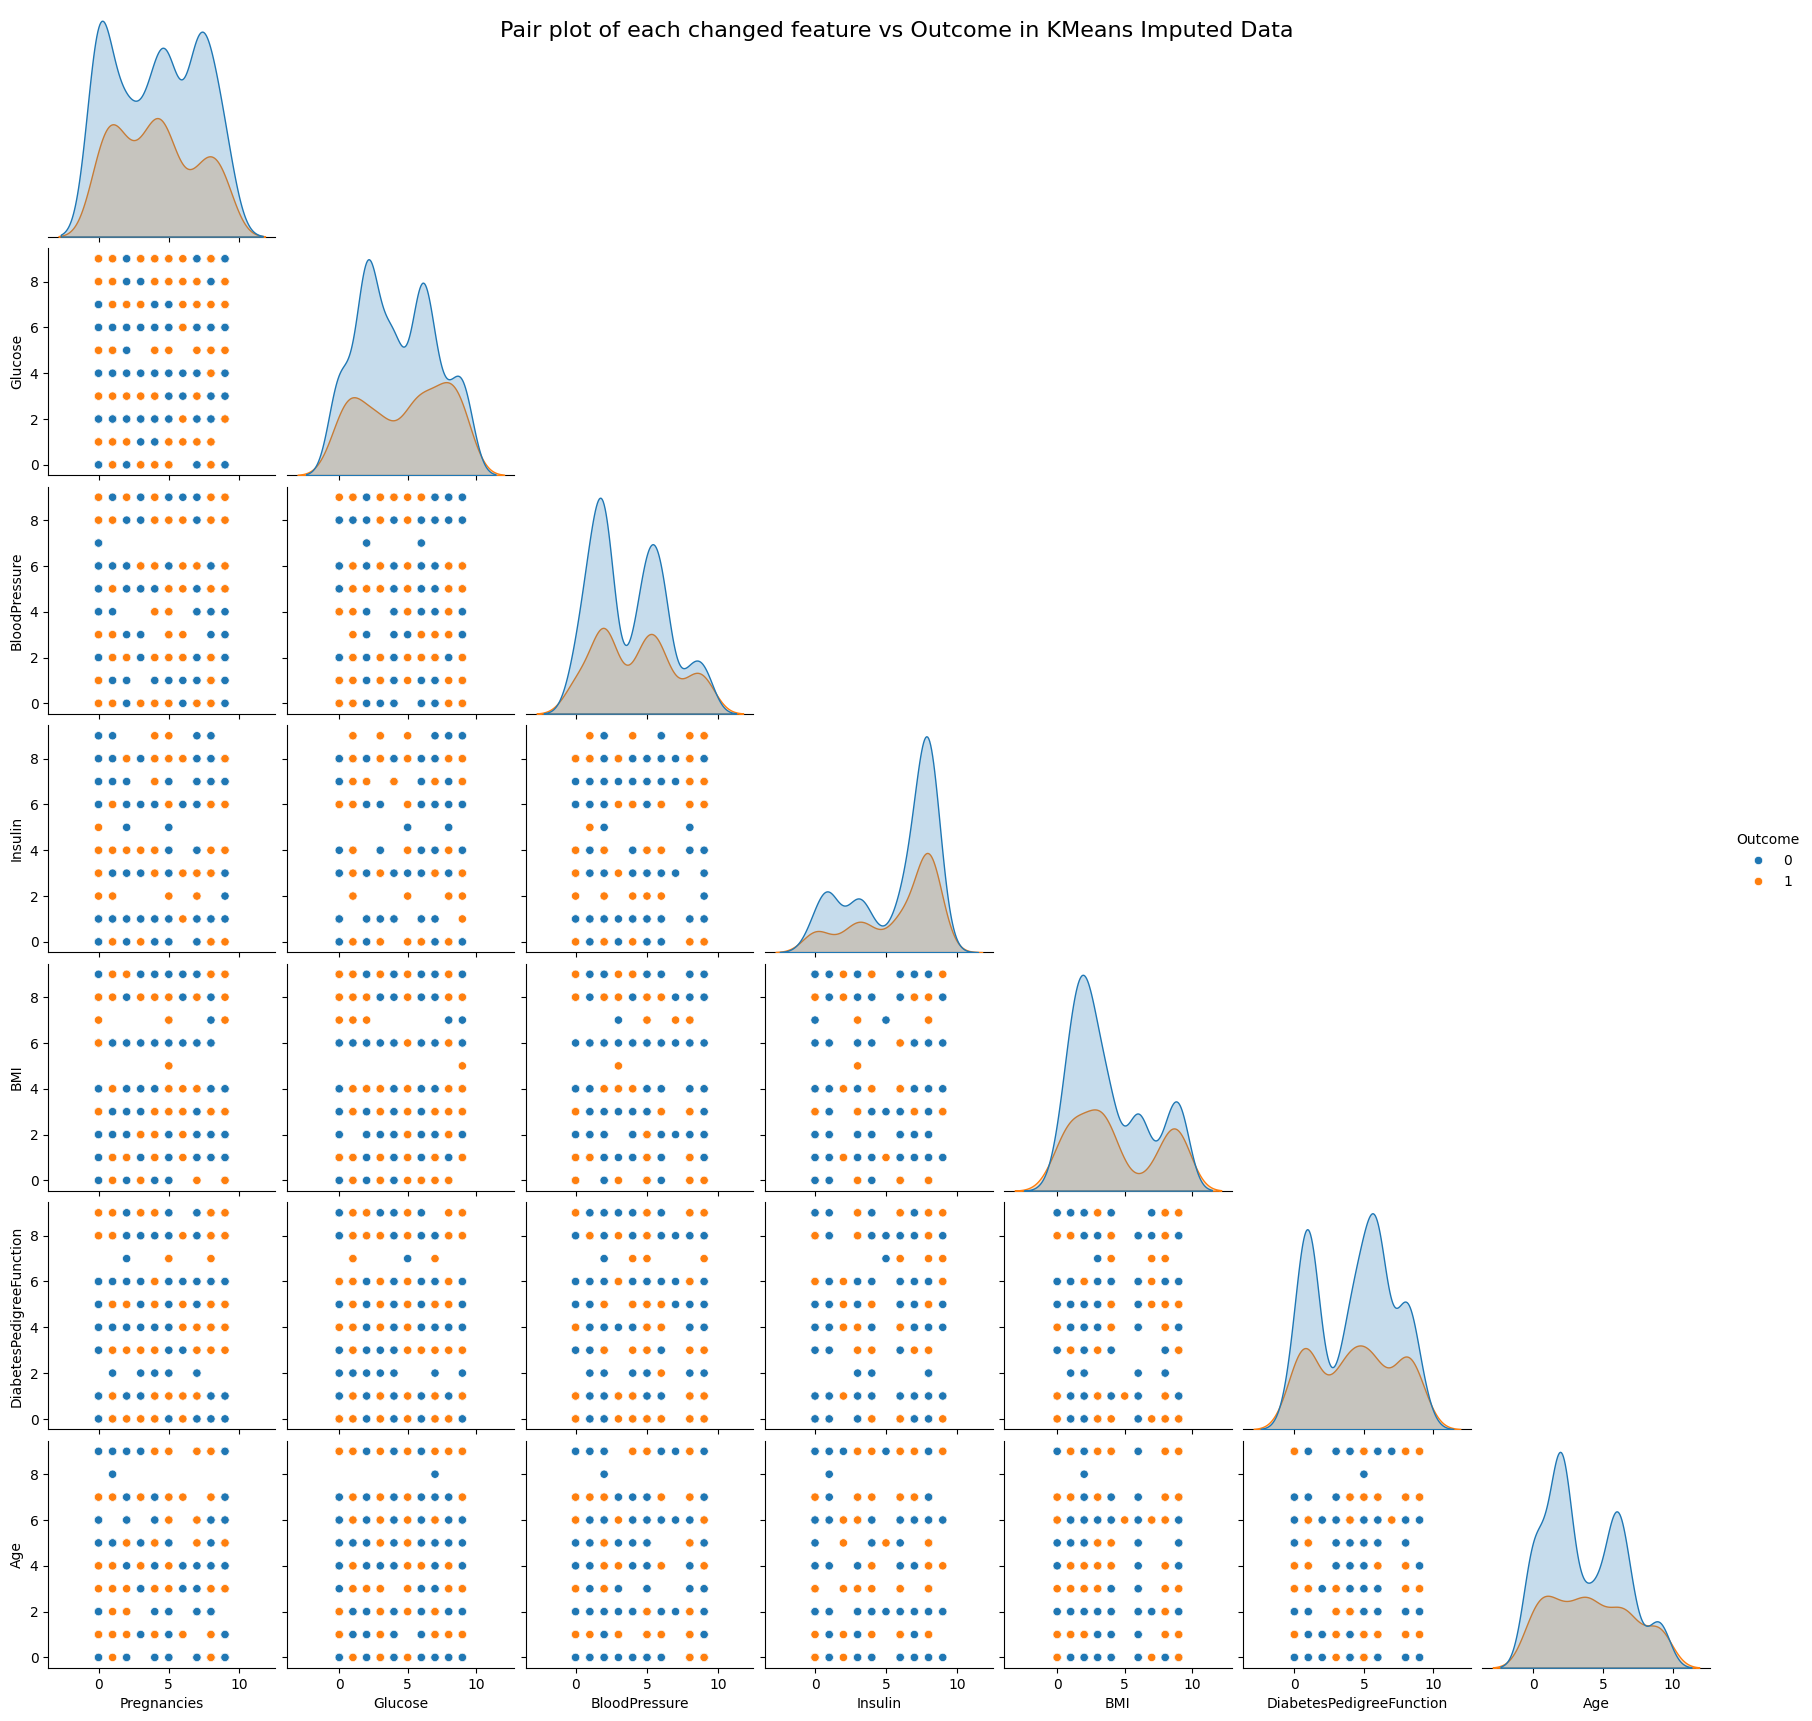

In [77]:
ploted_columns = df_kmeans.columns.tolist()
ploted_columns.remove("Outcome")
sns.pairplot(
    df_quantile,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in Quantile Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_quantile.png')
plt.show()
# knn kmeans
sns.pairplot(
    df_kmeans,
    vars=ploted_columns,
    hue="Outcome",
    corner=True
)
plt.suptitle('Pair plot of each changed feature vs Outcome in KMeans Imputed Data', fontsize=16)
plt.savefig('pair_plot_changed_features_vs_outcome_kmeans.png')
plt.show()



### Results
we can see kmeans discretization had bad effect on pair and correlation plots compared to quantile discretization. So we will go forward with quantile discretized dataset for building the Bayesian Network model.

## Training Bayesian Network

for Training Bayesian Network we will use pgmpy library. We will follow these steps:
1. Define the structure of the Bayesian Network which there is three options here:
   - we can define the structure manually based on domain knowledge.
   - we can use structure learning algorithms to learn the structure from data.
   - we can use a hybrid approach where we define some parts of the structure manually and learn other parts from data.
we will go through all three options and compare the results.

2. Find the Conditional Probability Distributions (CPDs) for each node in the network.
3. Perform inference on the Bayesian Network to make analyses with variable elimination. We will perform infrences to analyses the result of different scenarios.

### Define the structure of the Bayesian Network

#### Manually define the structure based on domain knowledge

in here we use the custom structure based on domain knowledge about diabetes.

This model will be our basic model which we connect the all features to the Outcome node directly. 

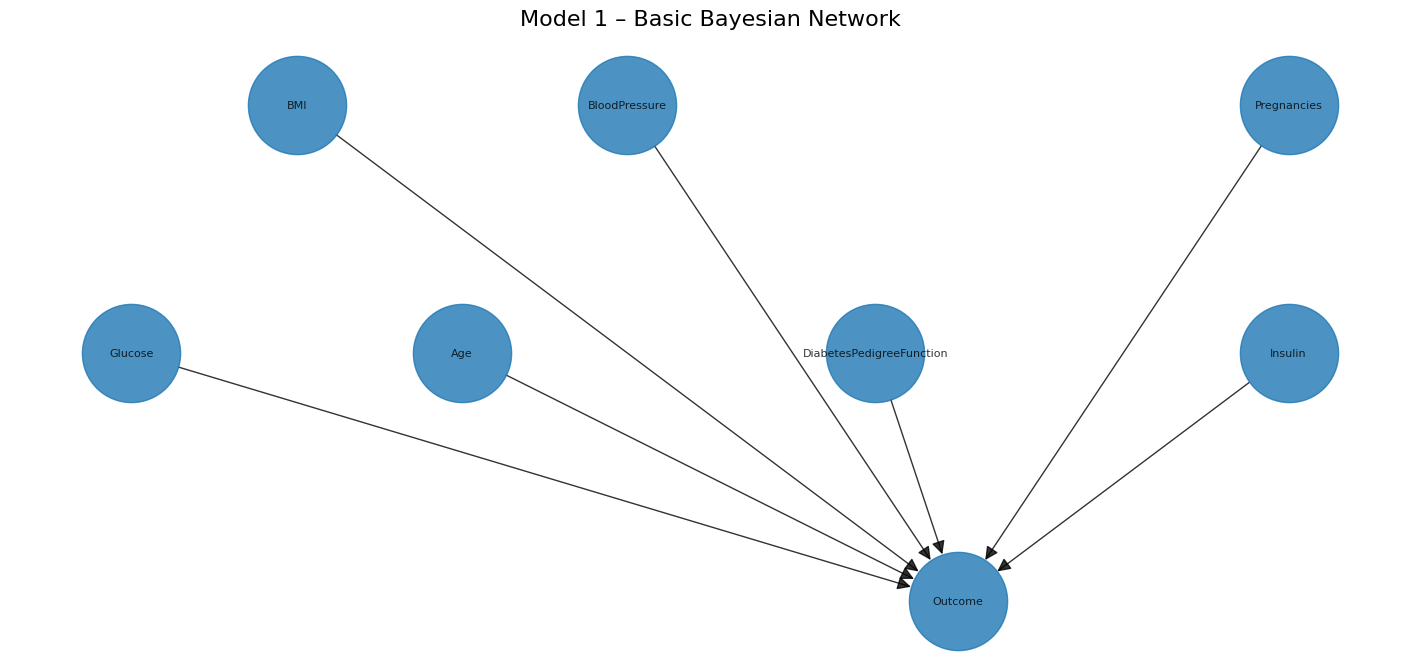

In [78]:
basic_model = DiscreteBayesianNetwork([
    ("Glucose", "Outcome"),
    ("BMI", "Outcome"),
    ("Age", "Outcome"),
    ("BloodPressure", "Outcome"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("Insulin", "Outcome"),
    ("Pregnancies", "Outcome"),
    
])

pos_basic = {
    "Glucose": (0, 2), "BMI": (2, 4), "Age": (4, 2),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (9, 2), "SkinThickness": (10, 4),
    "Insulin": (14, 2), "Pregnancies": (14, 4),
    "Outcome": (10, 0)
}

plt.figure(figsize=(14, 6))
nx.draw(basic_model, pos_basic, with_labels=True, node_size=5000,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 1 – Basic Bayesian Network", fontsize=16, pad=20)
plt.savefig('basic_bayesian_network.png')
plt.show()


Here is the second model where we connect the features based on their relations and influences on each other.

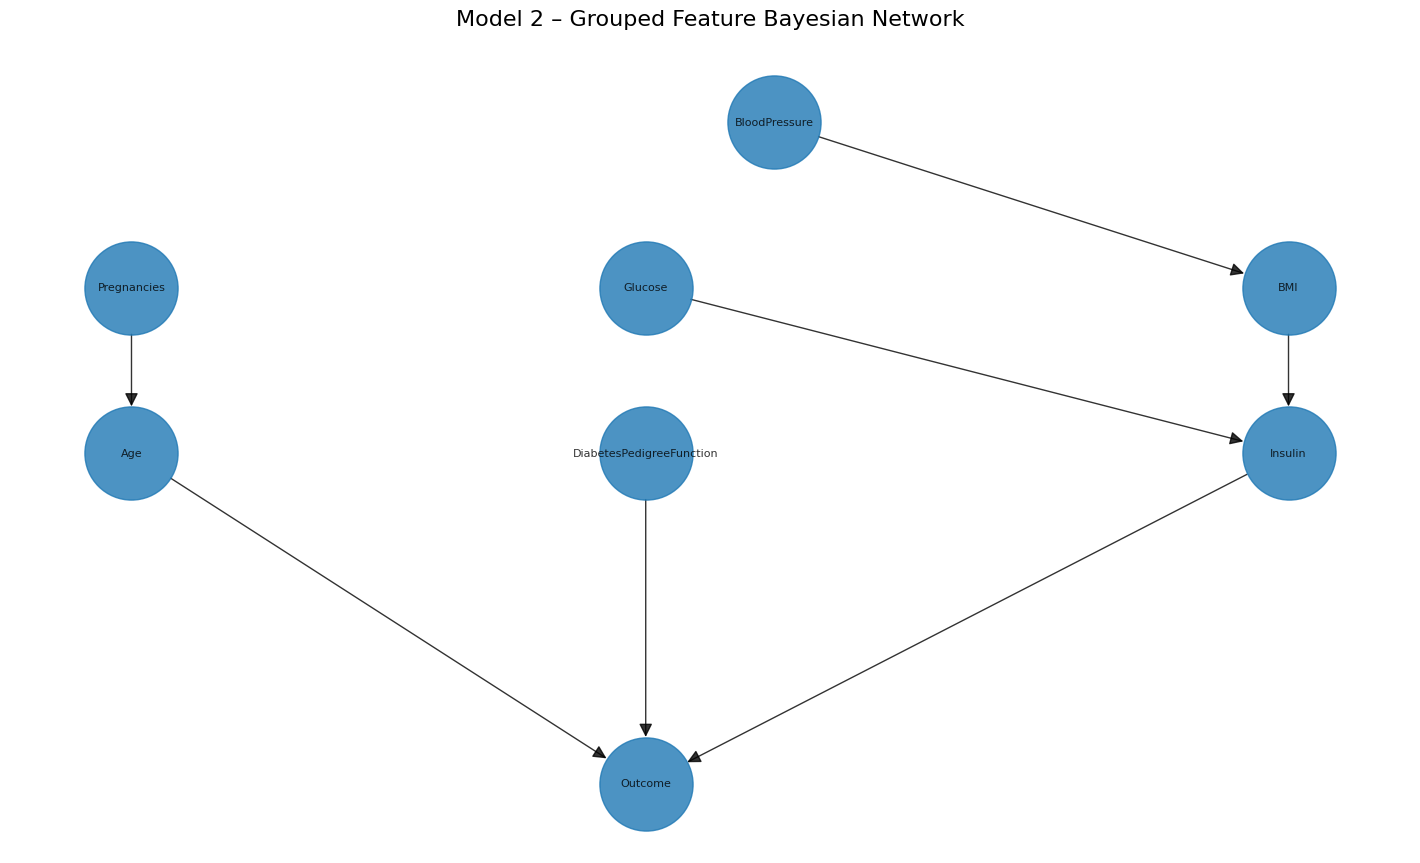

In [79]:
grouped_model = DiscreteBayesianNetwork([
   
    ("Glucose", "Insulin"),
    ("BMI", "Insulin"),
    ("Pregnancies", "Age"),
    ("BloodPressure", "BMI"),
    ("DiabetesPedigreeFunction", "Outcome") ,
    ("Insulin", "Outcome"),
    ("Age", "Outcome"),

    
])

pos_grouped = {
   "Glucose": (5, 3), "BMI": (10, 3), "SkinThickness": (12, 4),
    "Age": (1, 2),
    "Pregnancies": (1, 3),
    "BloodPressure": (6, 4), "DiabetesPedigreeFunction": (5, 2), "Insulin": (10, 2),
    "Outcome": (5, 0),
   
}

plt.figure(figsize=(14, 8))
nx.draw(grouped_model, pos_grouped, with_labels=True, node_size=4500,
        font_size=8, arrowsize=20, alpha=0.8)

plt.title("Model 2 – Grouped Feature Bayesian Network", fontsize=16, pad=20)
plt.savefig('grouped_feature_bayesian_network.png')
plt.show()


Here we use the structure learning algorithm to learn the structure from data.
First we will use Tree Search algorithm to learn the structure from data.
Then we will use Hill Climb Search algorithm to learn the structure from data.

We need to define the models for our data.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
Building tree: 100%|████████████████████████| 28/28.0 [00:00<00:00, 7516.67it/s]


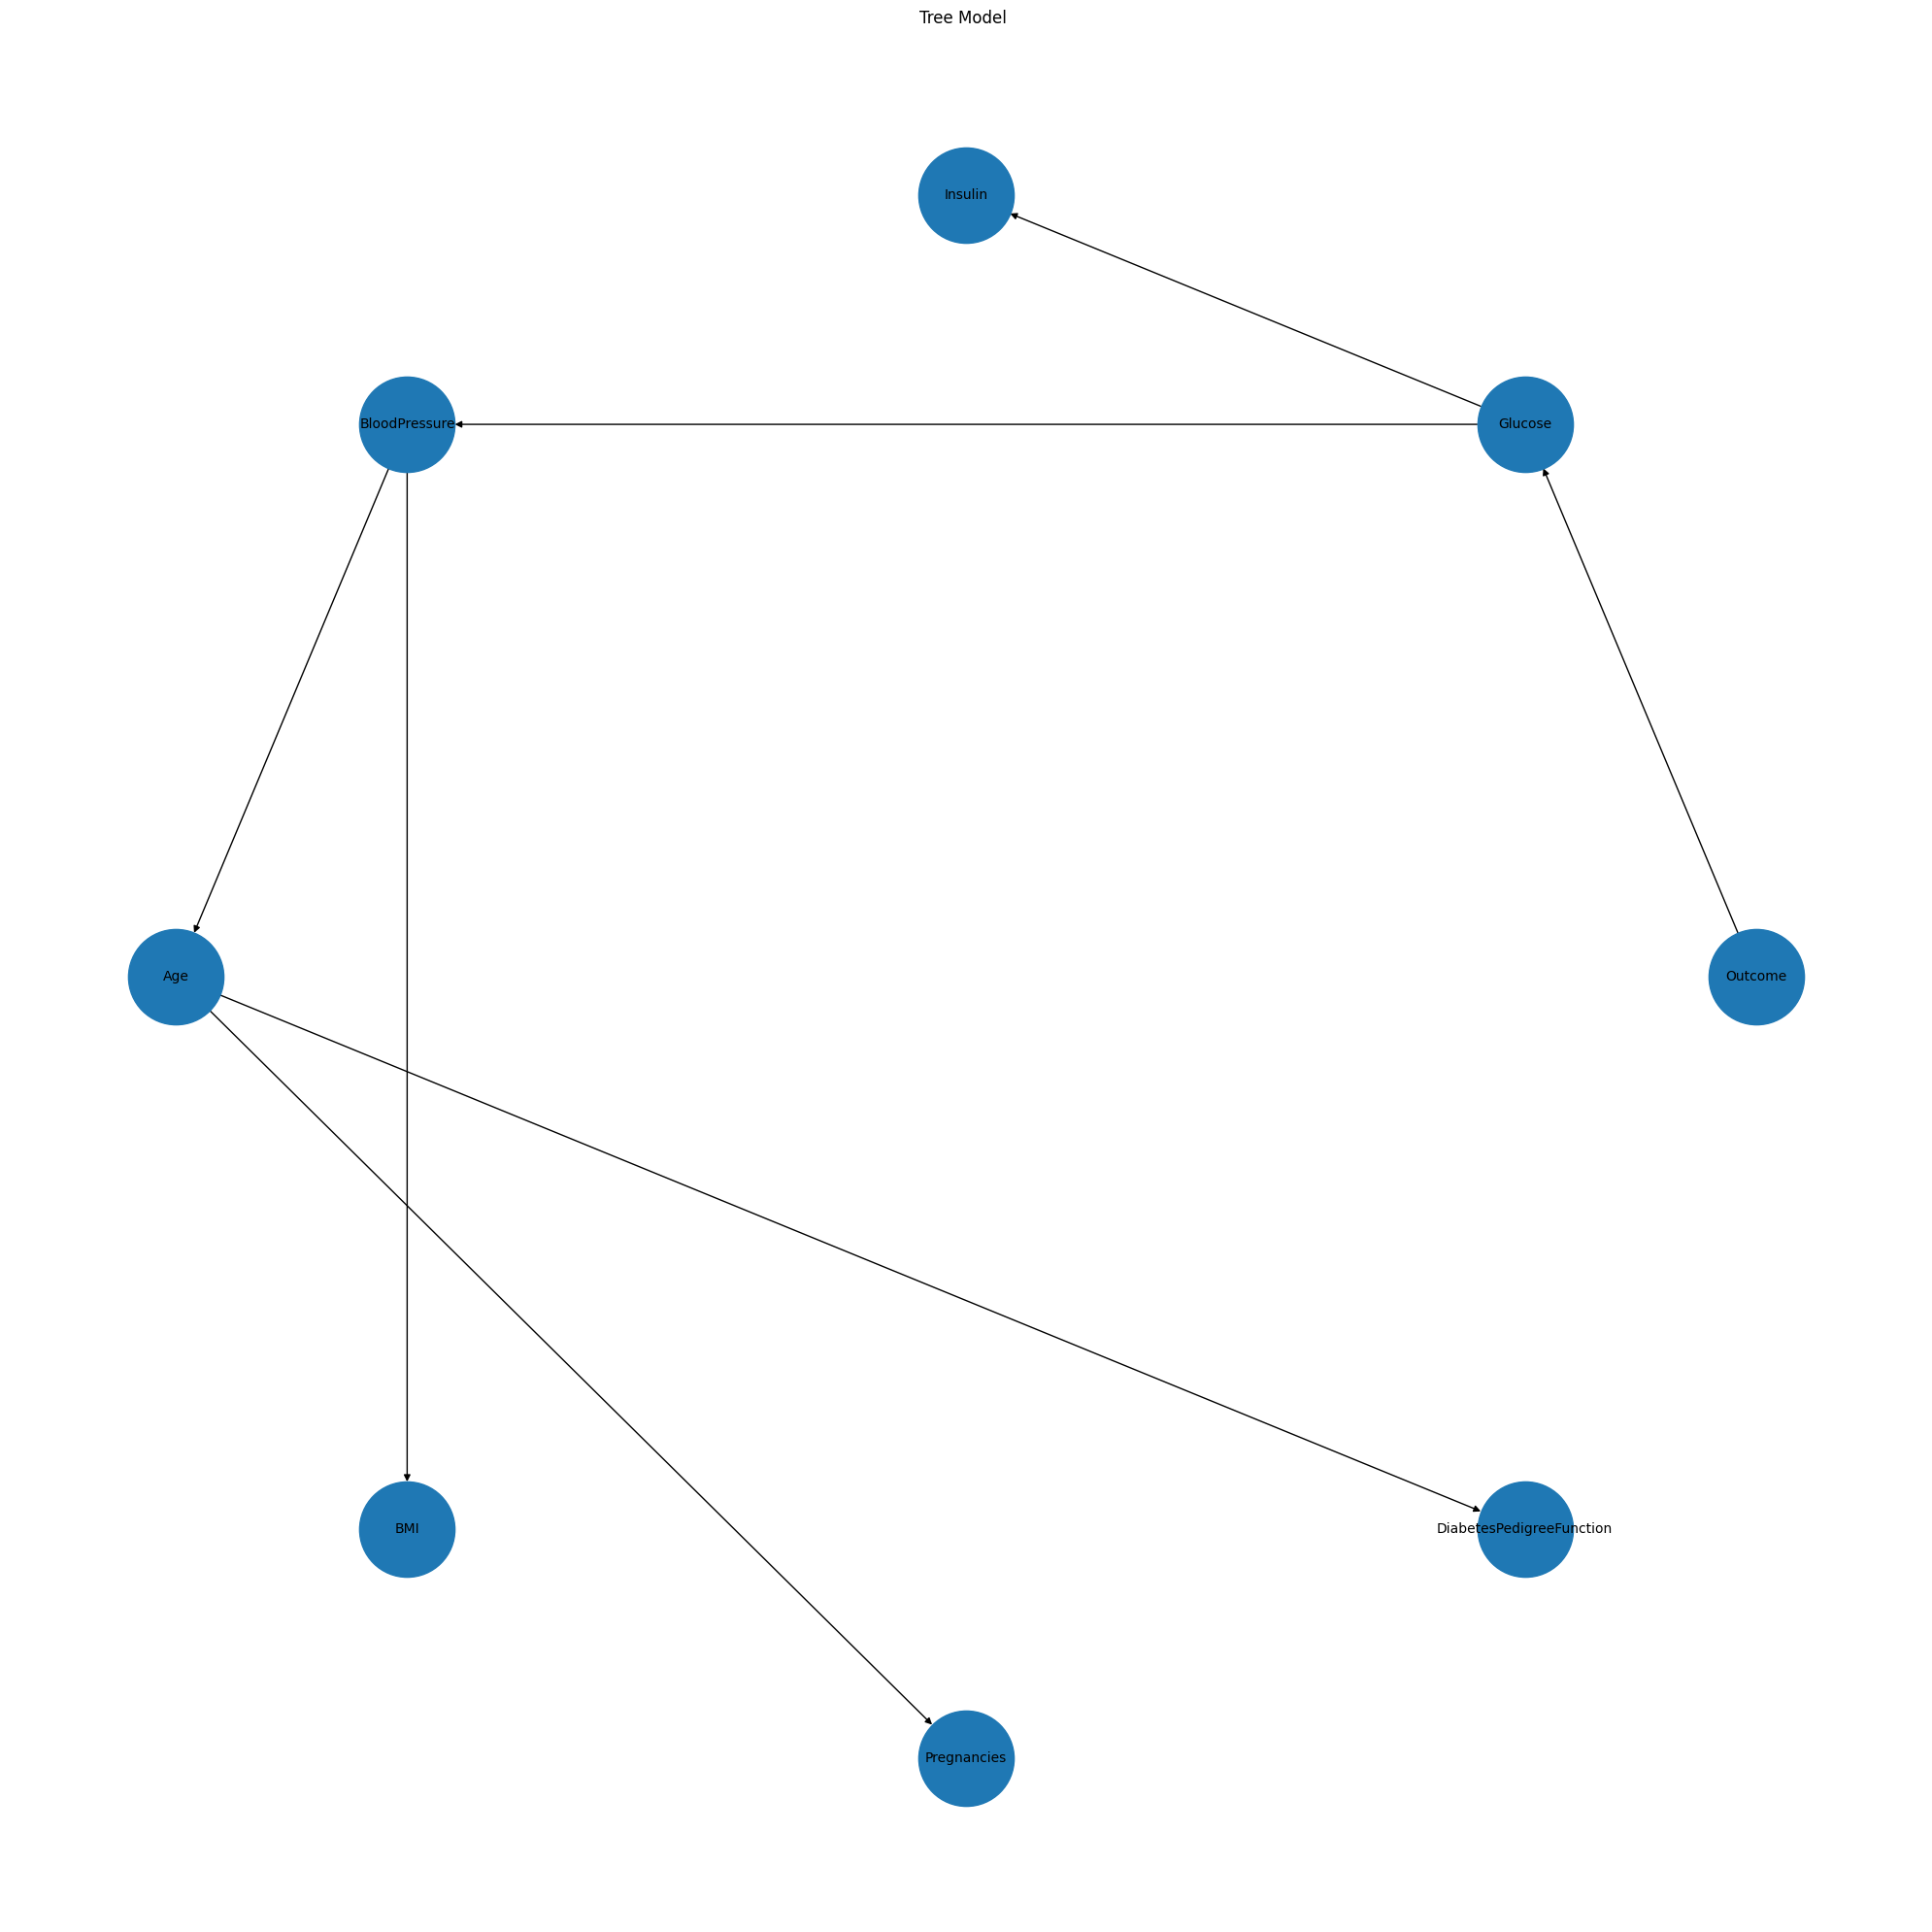

In [80]:
ts = TreeSearch(data=df_quantile, root_node="Outcome")
tree_model = ts.estimate(show_progress=True)


tree_models = [
    (tree_model, 'Tree Model '),
]
fig, axes = plt.subplots(1, 1, figsize=(20, 20))
axes = [axes]

for ax, (tree_model, title) in zip(axes, tree_models):
    pos = nx.drawing.layout.circular_layout(tree_model)

    nx.draw_networkx(
        tree_model,
        pos=pos,
        ax=ax,
        node_size=5000,
        font_size=10
    )

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_tree_models.png")
plt.show()
# define bayesian models based on learned structures
tree_models = {
    'tree': DiscreteBayesianNetwork(tree_model.edges()),
  
}


Here we do a hill climb search with diffrent scoring methods.
- k2
- AIC 

we have diffrent scoring methods and at all we have 5 diffrent models to compare plus 4 models from tree search and 2 custom models.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Out

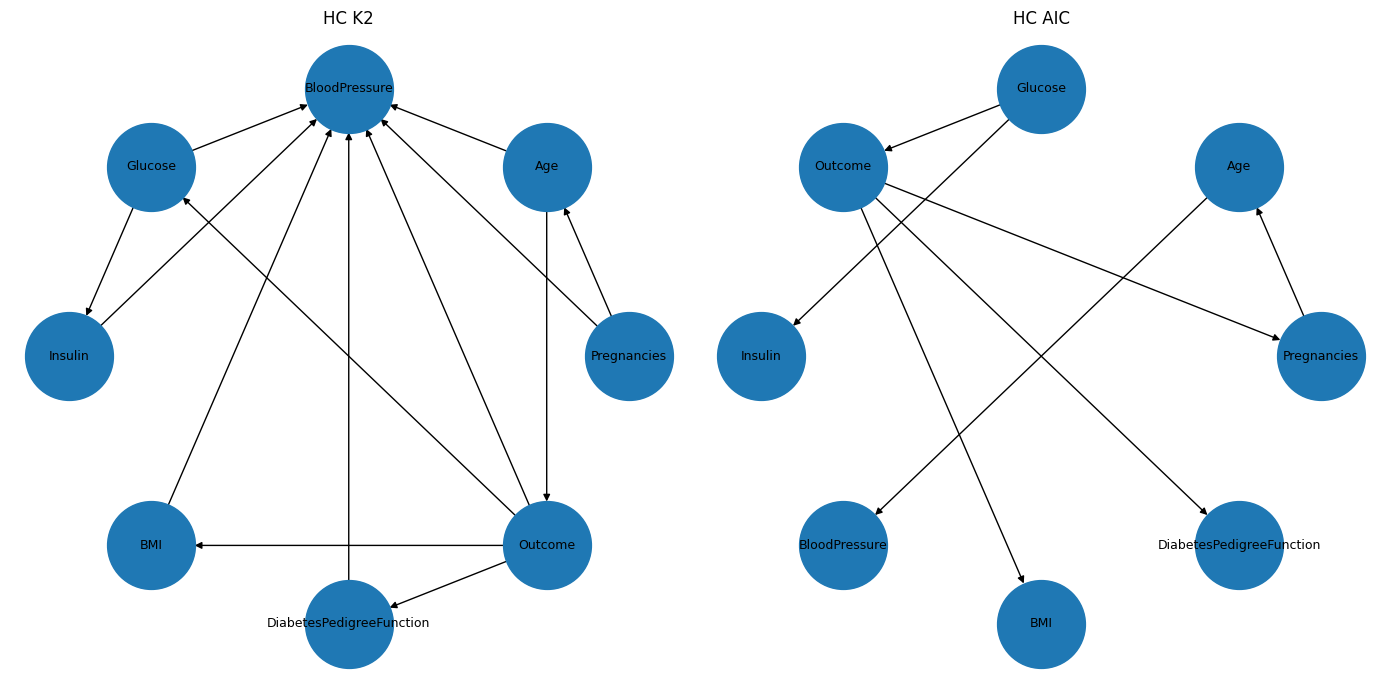

In [81]:
scorers = ['k2', 'aic']

hc_models = {}

for scorer_name in scorers:
    if scorer_name == 'k2':
        scorer = K2(df_quantile)
    elif scorer_name == 'aic':
        scorer = AIC(df_quantile)
    hc = HillClimbSearch(data=df_quantile)
    hc_model = hc.estimate(scoring_method=scorer, show_progress=False)
    model_key = f'hc_{scorer_name}'
    hc_models[model_key] = DiscreteBayesianNetwork(hc_model.edges())
        # plot the all models in one figure

fig, axes = plt.subplots(
    1,
    2,
    figsize=(7 * 2, 7 * 1)
)

axes = axes.flatten()

for ax, (model_key, hc_model) in zip(axes, hc_models.items()):
    pos = nx.drawing.layout.circular_layout(hc_model)

    nx.draw_networkx(
        hc_model,
        pos=pos,
        ax=ax,
        node_size=4000,
        font_size=9
    )

    title = model_key.replace('_', ' ').upper()
    ax.set_title(title)
    ax.axis("off")

# Hide unused subplots (if any)
for ax in axes[len(hc_models):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("all_hill_climb_models.png")
plt.show()




In [ ]:

models = [
        ('basic', basic_model),
          ('grouped', grouped_model),
            ('tree', tree_models['tree']),
            ('hc_k2', hc_models['hc_k2']),
            ('hc_aic', hc_models['hc_aic'])]

for name, model in models:
    print(f'Computing CDTs for {name} model')
    model.fit(df_quantile, estimator=MaximumLikelihoodEstimator)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CDTs for basic model


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Pregnancies': 'N', 'Glucose': 'N', 'BloodPressure': 'N', 'Insulin': 'N', 'BMI': 'N', 'DiabetesPedigreeFunction': 'N', 'Age': 'N', 'Outcome': 'N'}


Computing CDTs for grouped model
Computing CDTs for tree model
Computing CDTs for hc_k2 model


In [ ]:
nodes = ['Pregnancies', 'Glucose', 'BloodPressure',
         'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

for name, model in models:
    print(f'Result of  model: {name}')
    print(f'Independence assertions num: {len(model.get_independencies().get_assertions())}')
    print(f'Local semantics of the current model:\n{model.local_independencies(nodes)}')
    print('Checking Markov blankets')
    for node in nodes:
        print(f'The Markov blanket of node {node} is {model.get_markov_blanket(node)}')
    print()

Result of  model: basic
Independence assertions num: 21
Local semantics of the current model:
(Pregnancies ⟂ Age, BloodPressure, DiabetesPedigreeFunction, Glucose, Insulin, BMI)
(Glucose ⟂ Age, BloodPressure, Pregnancies, DiabetesPedigreeFunction, Insulin, BMI)
(BloodPressure ⟂ Age, Pregnancies, DiabetesPedigreeFunction, Glucose, Insulin, BMI)
(Insulin ⟂ Age, BloodPressure, Pregnancies, DiabetesPedigreeFunction, Glucose, BMI)
(BMI ⟂ Age, BloodPressure, Pregnancies, DiabetesPedigreeFunction, Glucose, Insulin)
(DiabetesPedigreeFunction ⟂ Age, BloodPressure, Pregnancies, Glucose, Insulin, BMI)
(Age ⟂ Pregnancies, BloodPressure, DiabetesPedigreeFunction, Glucose, Insulin, BMI)
Checking Markov blankets
The Markov blanket of node Pregnancies is ['Glucose', 'Insulin', 'Outcome', 'Age', 'BloodPressure', 'DiabetesPedigreeFunction', 'BMI']
The Markov blanket of node Glucose is ['Insulin', 'Outcome', 'Age', 'BloodPressure', 'Pregnancies', 'DiabetesPedigreeFunction', 'BMI']
The Markov blanket of n

In [ ]:
inferences = [(name, VariableElimination(model)) for name, model in models]

## Analyses 

In this section we are going to analys diffrent Questiions about the dataset

In [ ]:
# import matplotlib.pyplot as plt

# def plot_result(answer_scores: dict, file_name: str, title: str):
#     fig, axes = plt.subplots(3, 2, figsize=(15, 8), sharey=True)
#     axes = axes.flatten()

#     for ax, name in zip(axes, answer_scores.keys()):
#         ax.set_title(f"{name} model")

#         outcomes = {
#             "0": [],
#             "1": []
#         }

#         for _, probs in answer_scores[name].items():
#             # Expect probs like [p0, p1]
#             outcomes["0"].append(probs[0])
#             outcomes["1"].append(probs[1])

#         # ax.plot(outcomes["0"], label="Outcome 0")
#         ax.plot(outcomes["1"], label="Outcome 1")
#         ax.legend()

#     plt.suptitle(title, fontsize=16)
#     plt.tight_layout()
#     # plt.subplots_adjust(top=0.92)
#     fig.savefig(file_name)
#     plt.show()

In [ ]:
def plot_result(answer_scores: dict, file_name: str, title: str, x_values, x_label: str):
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=True)
    axes = axes.flatten()

    for ax, name in zip(axes, answer_scores.keys()):
        ax.set_title(f"{name} model")

        outcomes_1 = []

        for _, probs in answer_scores[name].items():
            outcomes_1.append(probs[1])  # P(Outcome = 1)

        ax.plot(x_values, outcomes_1, marker='o', label="P(Outcome=1)")
        ax.set_xlabel(x_label)
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    fig.savefig(file_name)
    plt.show()

In [ ]:
def print_outcome_change(answer_scores, variable_name="Age", condition_note=None):
    header = f"Change in P(Outcome=1) as {variable_name} increases"
    if condition_note:
        header += f" ({condition_note})"

    print(f"\n{header}:\n")

    for model_name, results in answer_scores.items():
        probs = [v[1] for v in results.values()]  # Outcome = 1

        start = probs[0]
        end = probs[-1]
        abs_change = end - start

        if start > 0:
            pct_change = (abs_change / start) * 100
            pct_str = f"{pct_change:+.1f}%"
        else:
            pct_str = "undefined"

        print(
            f"{model_name:10s} | "
            f"start={start:.3f}, end={end:.3f}, "
            f"Δ={abs_change:+.3f} ({pct_str})"
        )

### Question 1: How does diabetes risk change when Age increases while Glucose remains high?

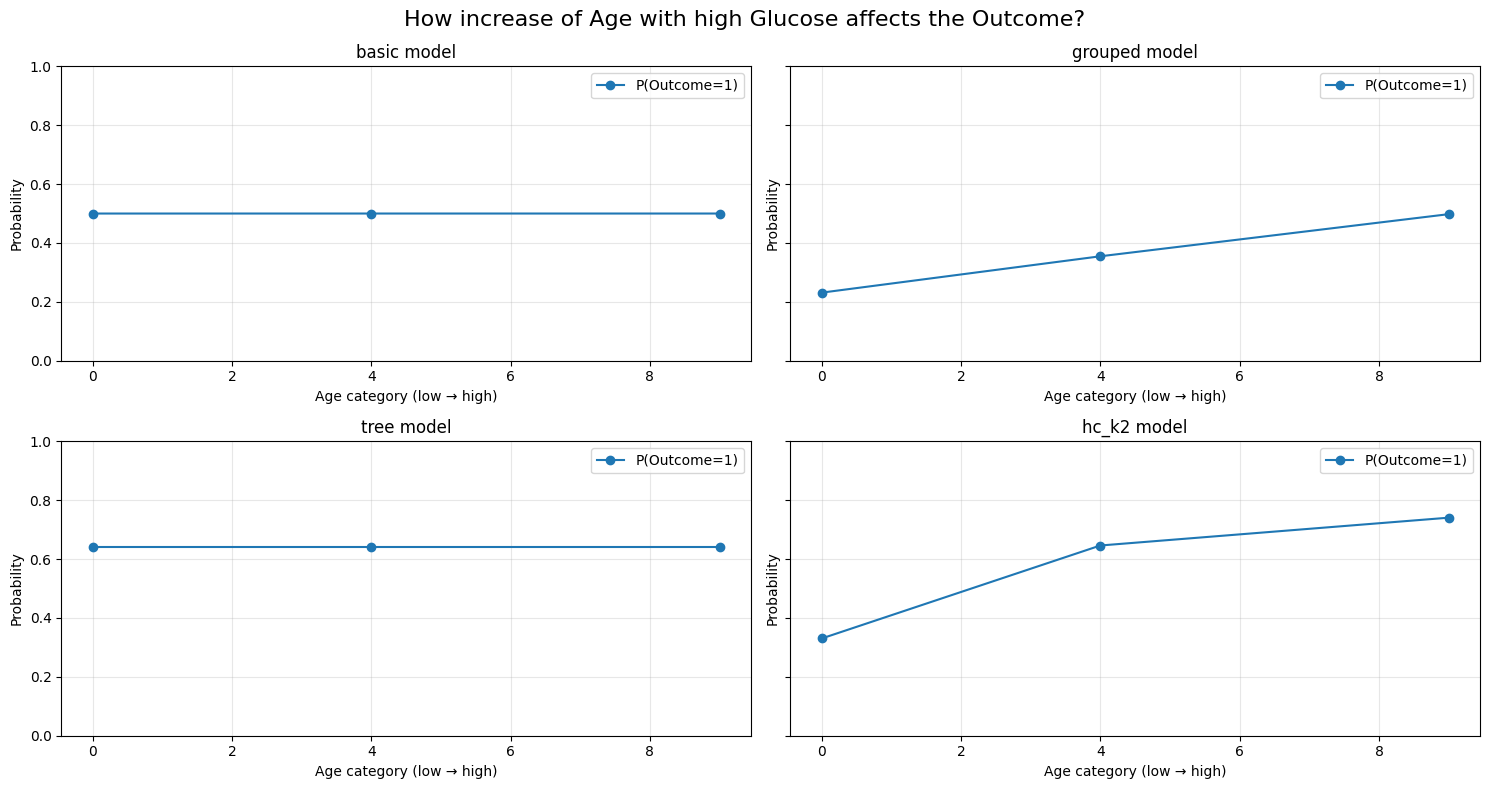


Change in P(Outcome=1) as Age increases (Glucose fixed high):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.231, end=0.498, Δ=+0.267 (+115.2%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.330, end=0.741, Δ=+0.410 (+124.2%)
hc_aic     | start=0.542, end=0.704, Δ=+0.162 (+29.9%)


In [ ]:
title = "How increase of Age with high Glucose affects the Outcome?"
scores = [(0,8), (4,8), (9,8)]  # (Age, Glucose)

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot results ----
plot_result(
    answer_scores,
    'question1.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Print compact change summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="Glucose fixed high"
)


### Question 2: Does high BMI amplify diabetes risk for young individuals?

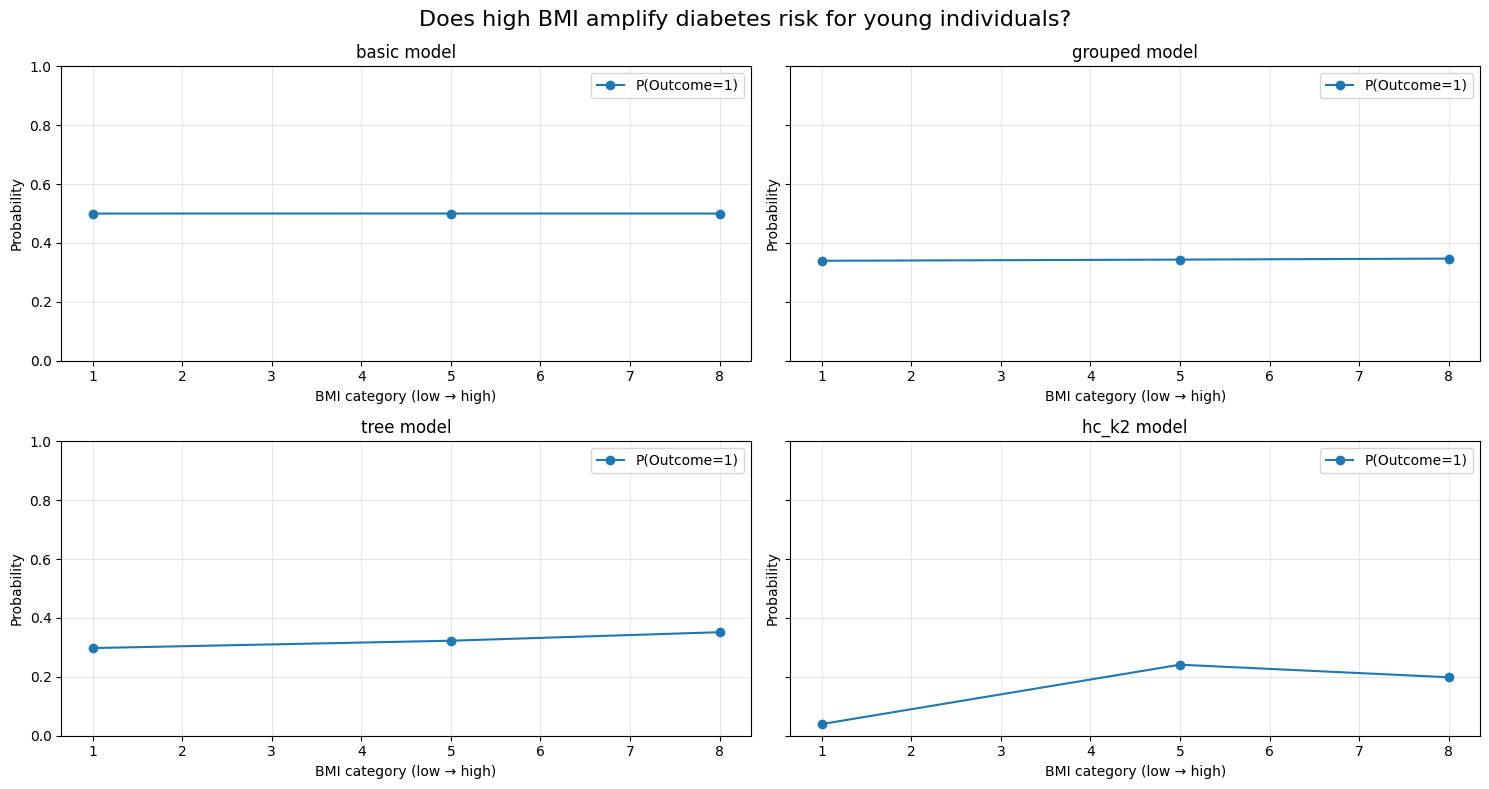


Change in P(Outcome=1) as BMI increases (Age fixed at low):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.339, end=0.347, Δ=+0.007 (+2.2%)
tree       | start=0.298, end=0.352, Δ=+0.054 (+18.1%)
hc_k2      | start=0.040, end=0.199, Δ=+0.159 (+401.5%)
hc_aic     | start=0.064, end=0.292, Δ=+0.228 (+354.5%)


In [ ]:
# Question 2: Does high BMI amplify diabetes risk for young individuals?

title = "Does high BMI amplify diabetes risk for young individuals?"
scores = [(1, 1), (1, 5), (1, 8)]  # (Age, BMI)

answer_scores = {}
x_values = [bmi for _, bmi in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question2.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at low"
)


### Question 3: Can low BMI reduce diabetes risk even at high Glucose levels?

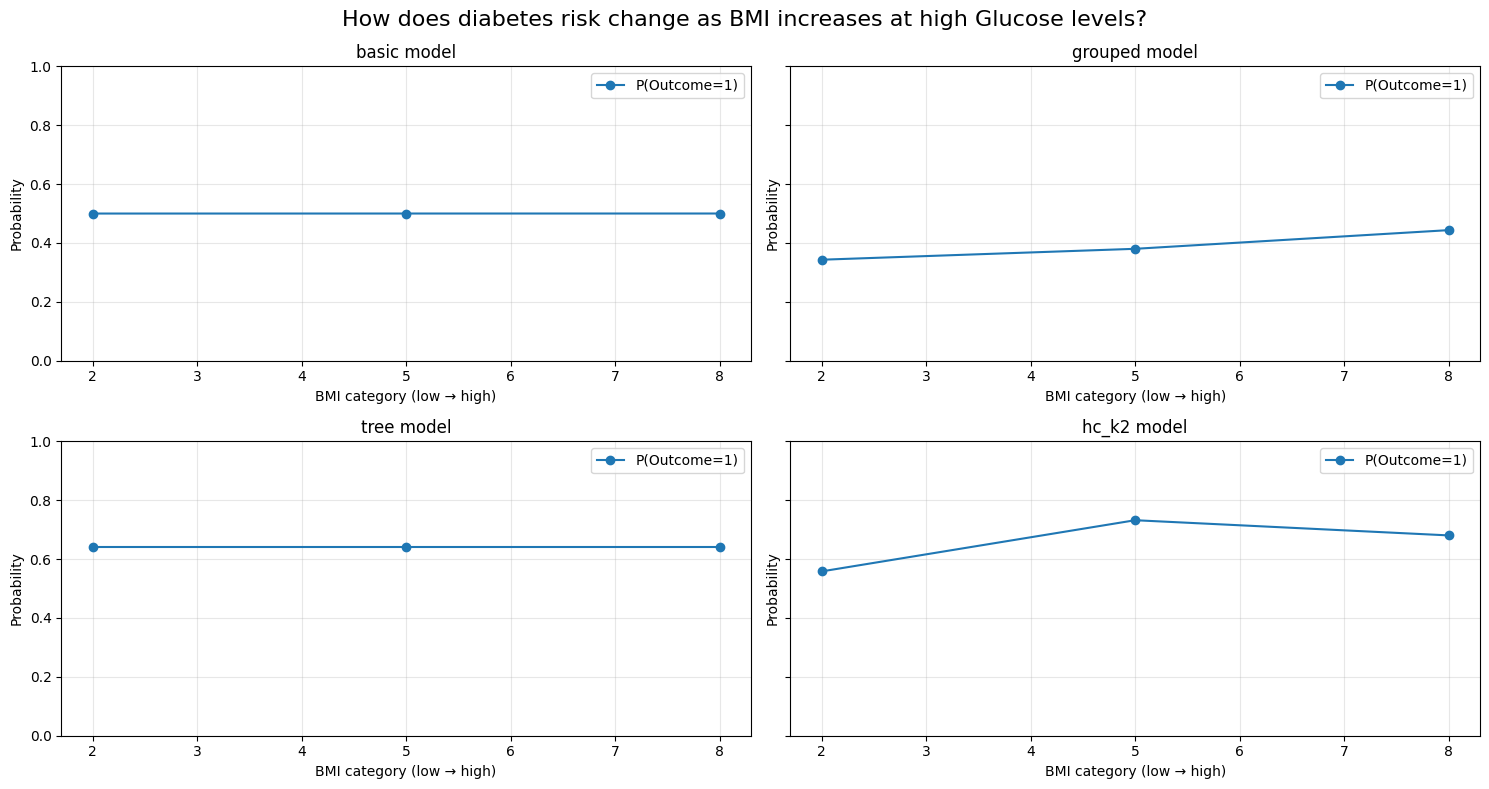


Change in P(Outcome=1) as BMI increases (Glucose fixed high):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.343, end=0.444, Δ=+0.100 (+29.3%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.558, end=0.680, Δ=+0.122 (+21.9%)
hc_aic     | start=0.558, end=0.680, Δ=+0.122 (+21.9%)


In [ ]:
title ="How does diabetes risk change as BMI increases at high Glucose levels?"
scores = [(2, 8), (5, 8), (8, 8)]  # (BMI, Glucose)

answer_scores = {}
x_values = [bmi for bmi, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for bmi, glucose in scores:
        evidence = {"BMI": bmi, "Glucose": glucose}
        answer_scores[name][(bmi, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question3.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Glucose fixed high"
)

### Question 4: Is Age or BMI the dominant risk factor when they disagree?

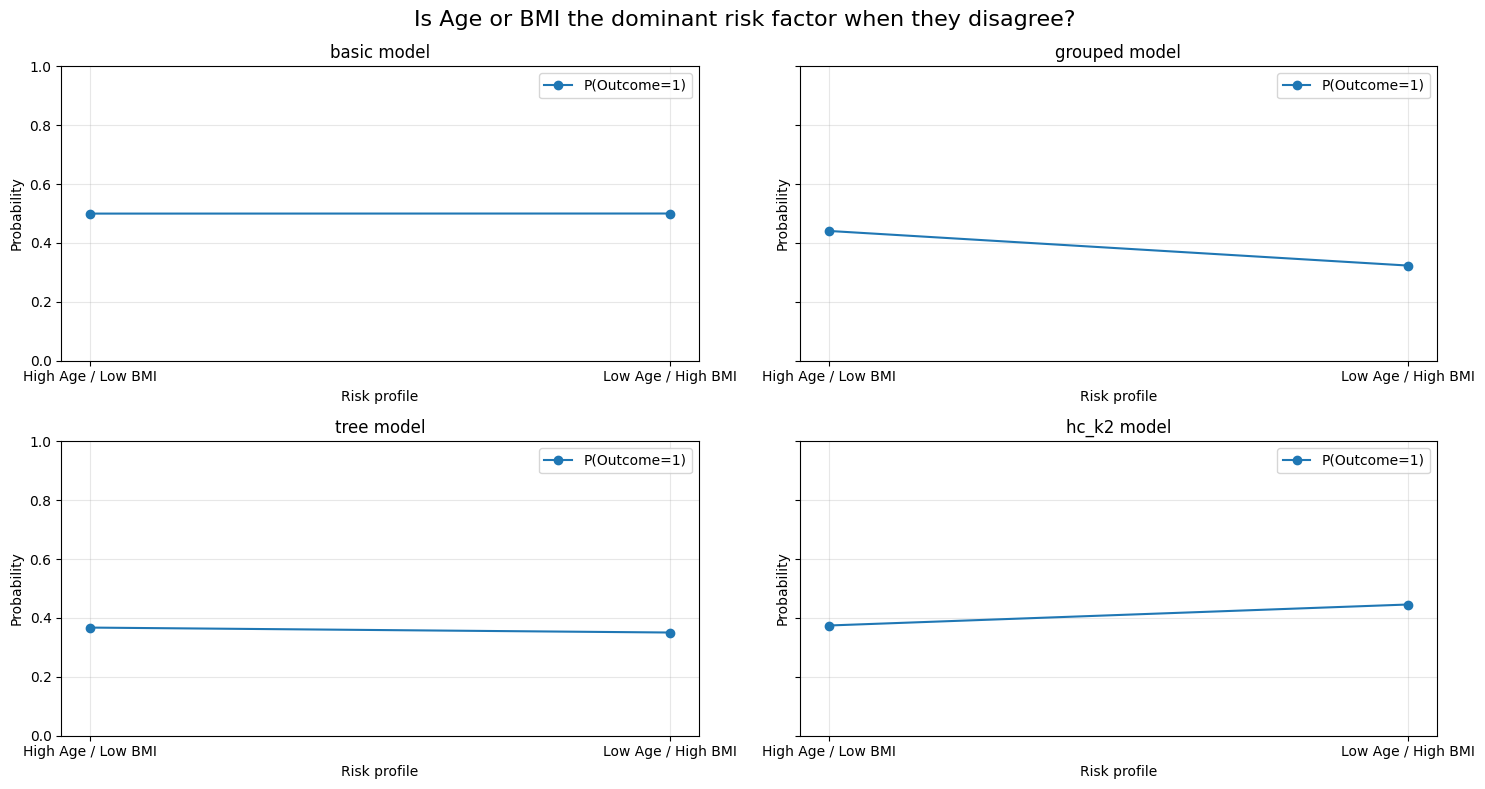


Change in P(Outcome=1) as Risk profile increases (Age vs BMI trade-off):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.1%)
grouped    | start=0.441, end=0.323, Δ=-0.118 (-26.7%)
tree       | start=0.367, end=0.351, Δ=-0.017 (-4.6%)
hc_k2      | start=0.374, end=0.446, Δ=+0.071 (+19.1%)
hc_aic     | start=0.333, end=0.505, Δ=+0.172 (+51.8%)


In [ ]:
# Question 4: Is Age or BMI the dominant risk factor when they disagree?

title = "Is Age or BMI the dominant risk factor when they disagree?"
scores = [
    (9, 2),  # High Age, Low BMI
    (2, 9)   # Low Age, High BMI
]

answer_scores = {}
x_values = ["High Age / Low BMI", "Low Age / High BMI"]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question4.png',
    title,
    x_values,
    x_label="Risk profile"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Risk profile",
    condition_note="Age vs BMI trade-off"
)


### Question 5: How does diabetes probability evolve across Age bins for average BMI?

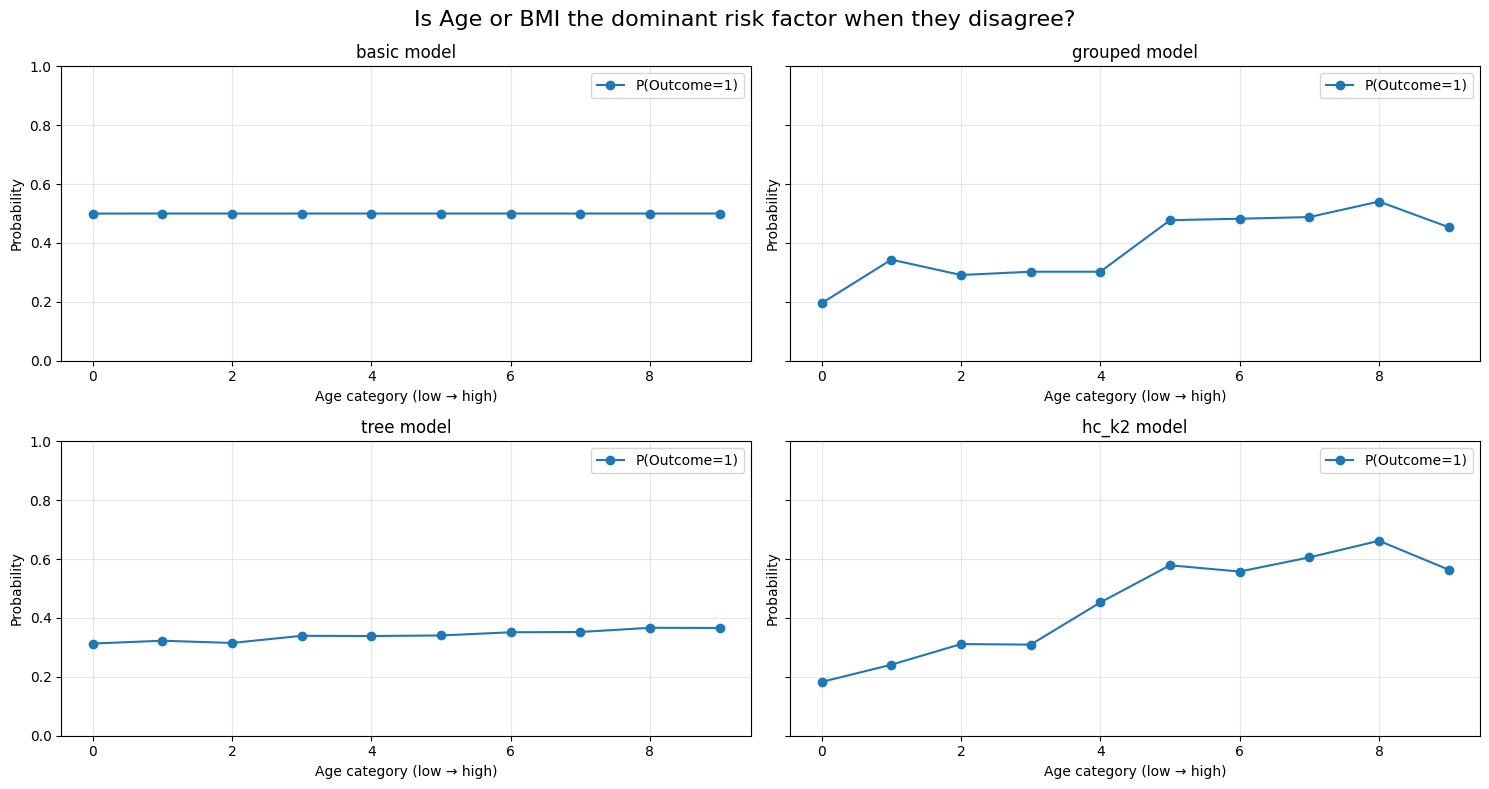


Change in P(Outcome=1) as Age increases (BMI fixed at average):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.195, end=0.454, Δ=+0.258 (+132.1%)
tree       | start=0.313, end=0.366, Δ=+0.053 (+16.9%)
hc_k2      | start=0.183, end=0.564, Δ=+0.381 (+208.8%)
hc_aic     | start=0.349, end=0.519, Δ=+0.170 (+48.7%)


In [ ]:
ttile = "How does diabetes probability evolve across Age bins for average BMI?"
scores = [(age, 5) for age in range(10)]  # Age varies, BMI fixed at average

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question5.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="BMI fixed at average"
)

### Question 6: At what Glucose level does diabetes risk exceed 50% for elderly individuals?

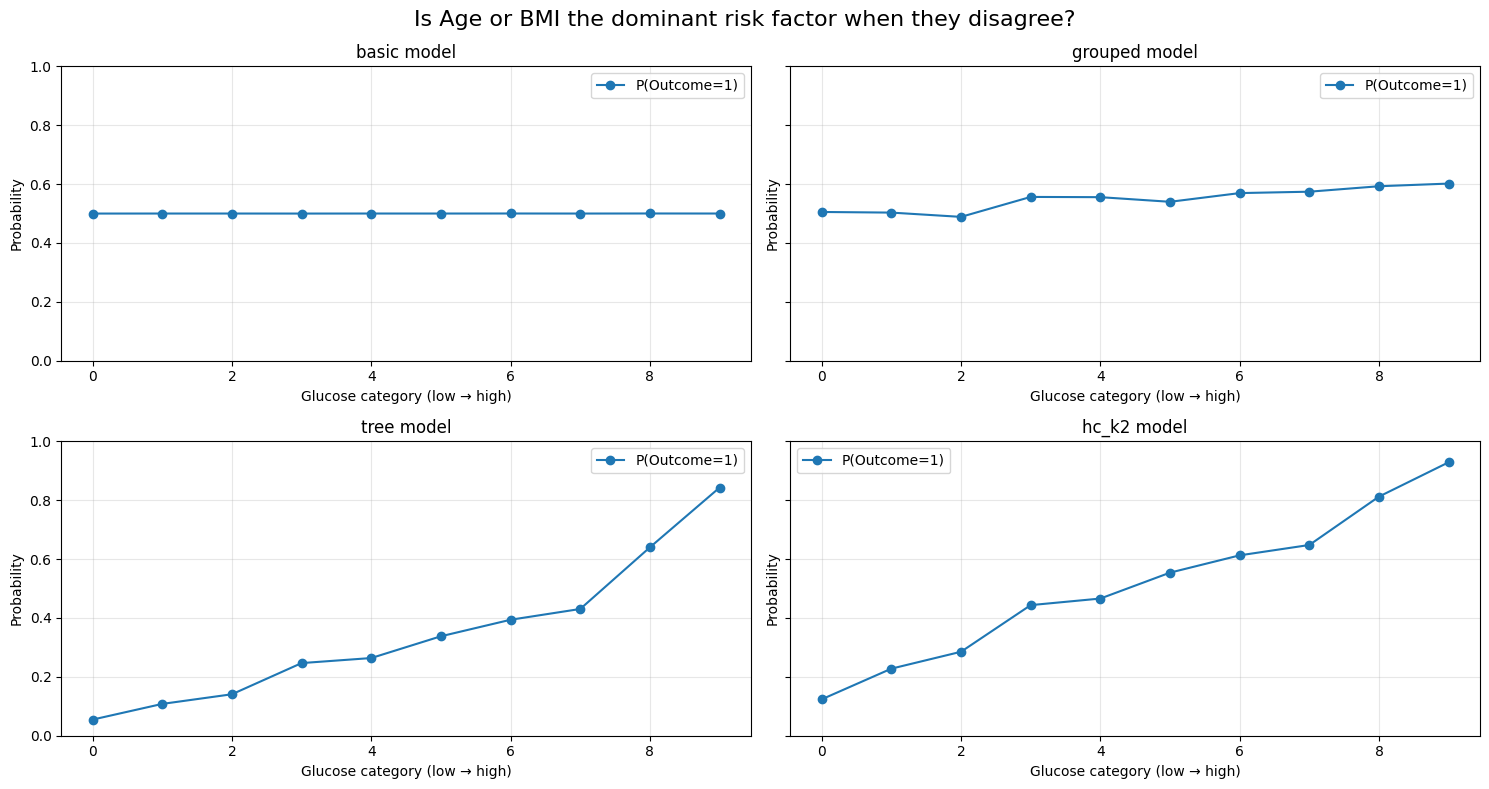


Change in P(Outcome=1) as Glucose increases (Age fixed at high (elderly)):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.505, end=0.602, Δ=+0.096 (+19.1%)
tree       | start=0.055, end=0.843, Δ=+0.788 (+1438.2%)
hc_k2      | start=0.124, end=0.929, Δ=+0.805 (+651.2%)
hc_aic     | start=0.086, end=0.897, Δ=+0.811 (+943.7%)


In [ ]:
titile= "At what Glucose level does diabetes risk exceed 50% for elderly individuals?"
scores = [(8, g) for g in range(10)]  # Age fixed high (elderly), Glucose varies

answer_scores = {}
x_values = [glucose for _, glucose in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question6.png',
    title,
    x_values,
    x_label="Glucose category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Glucose",
    condition_note="Age fixed at high (elderly)"
)

### Question 7: Does moderate BMI increase diabetes risk for middle-aged individuals?

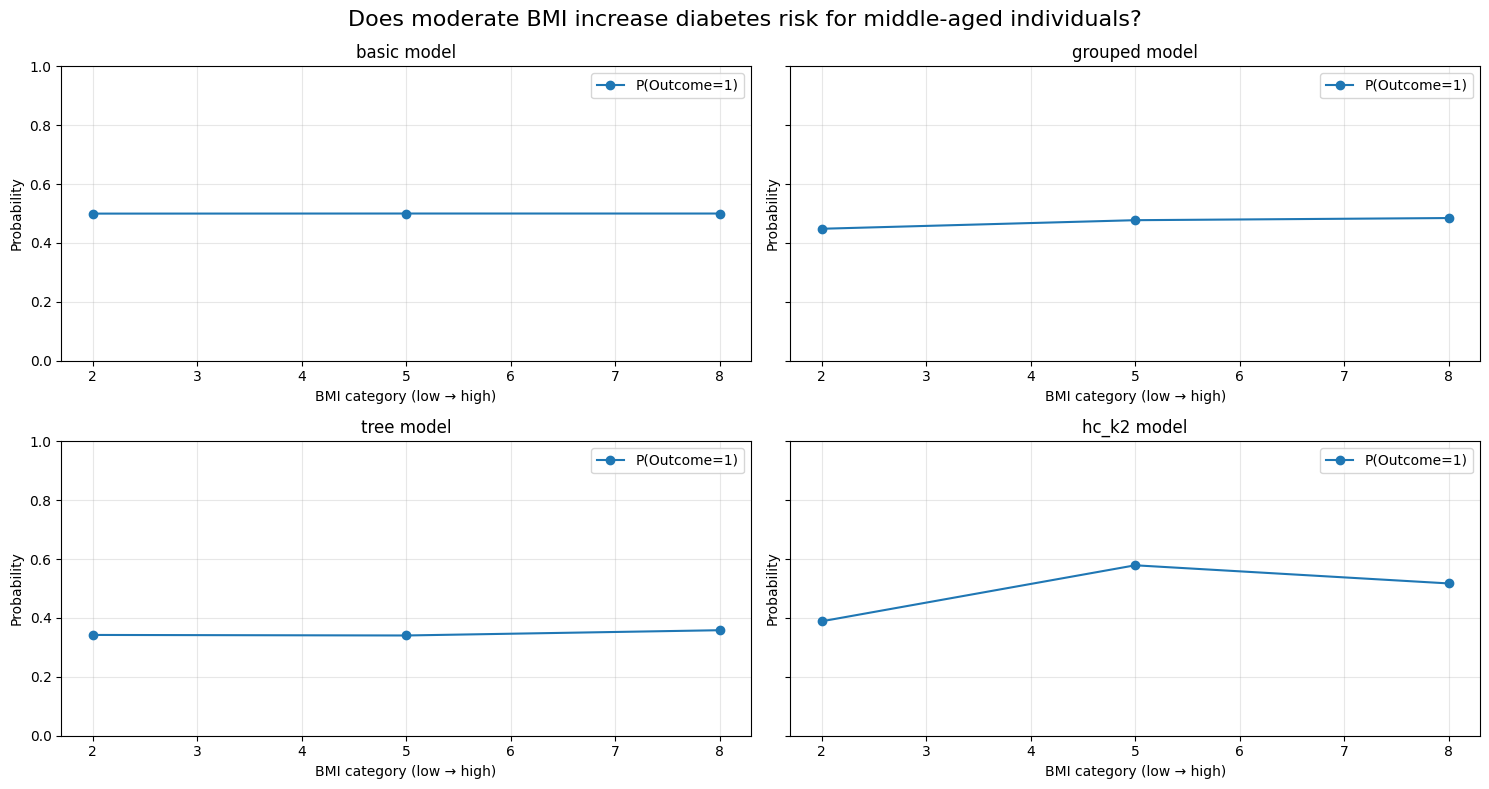


Change in P(Outcome=1) as BMI increases (Age fixed at middle):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.448, end=0.485, Δ=+0.036 (+8.1%)
tree       | start=0.342, end=0.358, Δ=+0.016 (+4.7%)
hc_k2      | start=0.389, end=0.517, Δ=+0.129 (+33.1%)
hc_aic     | start=0.281, end=0.397, Δ=+0.116 (+41.3%)


In [ ]:
title = "Does moderate BMI increase diabetes risk for middle-aged individuals?"
scores = [(5, b) for b in [2, 5, 8]]  # Age fixed at middle, BMI varies

answer_scores = {}
x_values = [bmi for _, bmi in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question7.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at middle"
)

### Question 8: Is high Glucose alone sufficient to induce high diabetes risk?

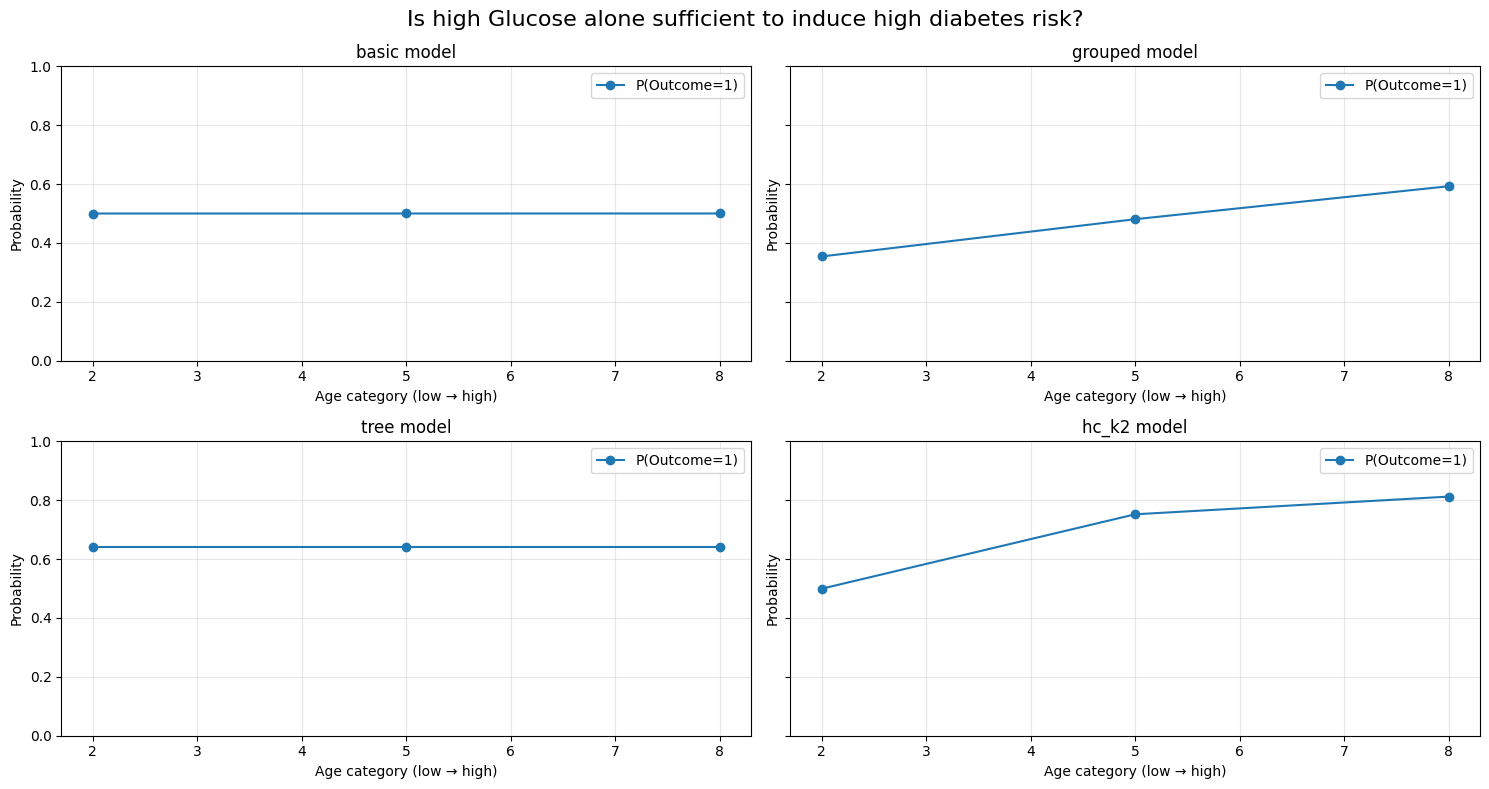


Change in P(Outcome=1) as Age increases (Glucose fixed high):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.354, end=0.593, Δ=+0.239 (+67.3%)
tree       | start=0.640, end=0.640, Δ=+0.000 (+0.0%)
hc_k2      | start=0.499, end=0.812, Δ=+0.313 (+62.7%)
hc_aic     | start=0.559, end=0.742, Δ=+0.184 (+32.9%)


In [ ]:
title = "Is high Glucose alone sufficient to induce high diabetes risk?"
scores = [(2, 8), (5, 8), (8, 8)]  # Age varies, Glucose fixed high

answer_scores = {}
x_values = [age for age, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, glucose in scores:
        evidence = {"Age": age, "Glucose": glucose}
        answer_scores[name][(age, glucose)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question8.png',
    title,
    x_values,
    x_label="Age category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Age",
    condition_note="Glucose fixed high"
)

### Question 9: How does diabetes risk differ between young-obese and old-lean individuals?

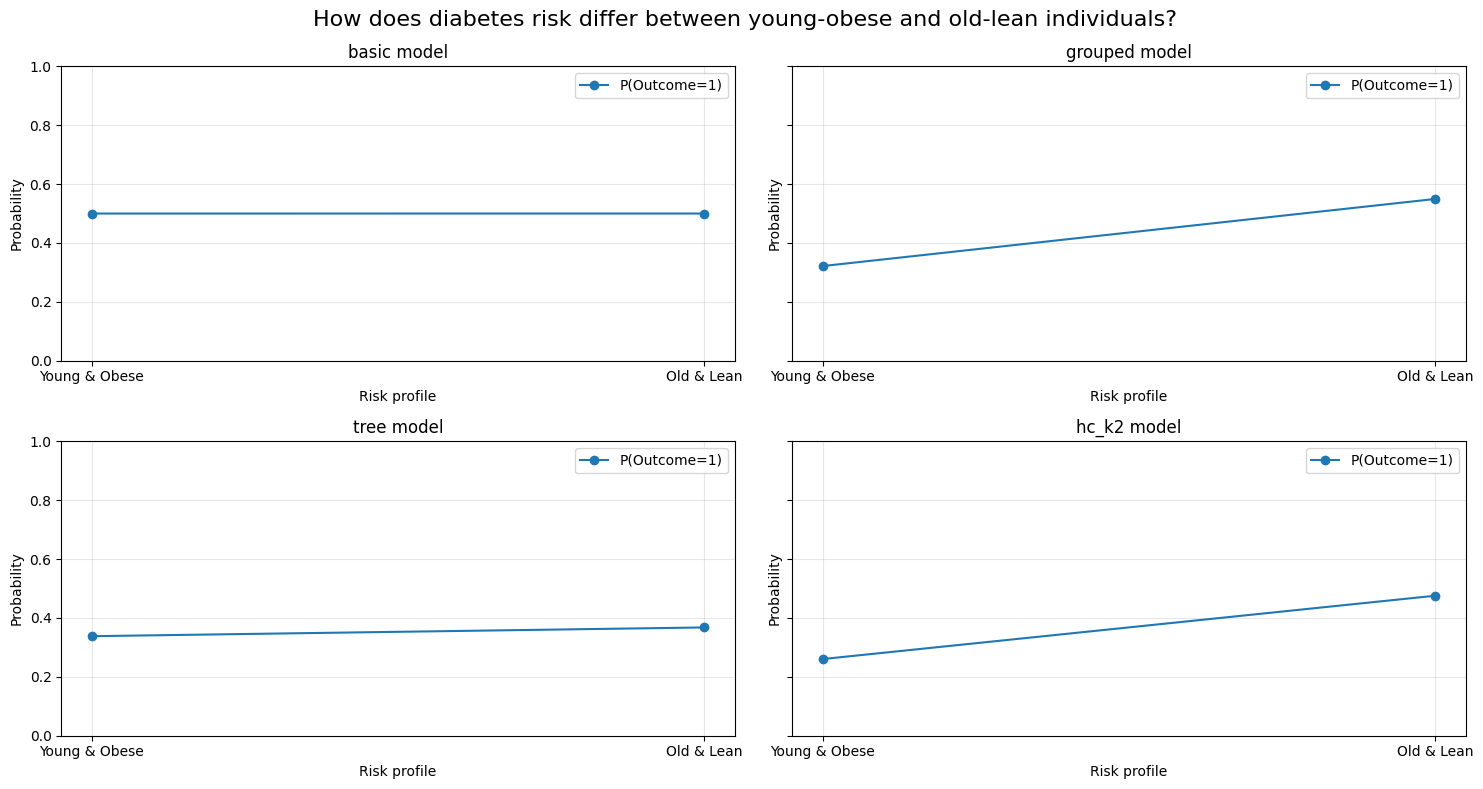


Change in P(Outcome=1) as Risk profile increases (Young-obese vs Old-lean):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.322, end=0.549, Δ=+0.228 (+70.8%)
tree       | start=0.338, end=0.368, Δ=+0.030 (+8.8%)
hc_k2      | start=0.261, end=0.476, Δ=+0.215 (+82.5%)
hc_aic     | start=0.309, end=0.377, Δ=+0.068 (+21.9%)


In [ ]:
title = "How does diabetes risk differ between young-obese and old-lean individuals?"
scores = [
    {"Age": 2, "BMI": 8},  # Young, obese
    {"Age": 8, "BMI": 2}   # Old, lean
]

answer_scores = {}
x_values = ["Young & Obese", "Old & Lean"]

for name, ve in inferences:
    answer_scores[name] = {}
    for s in scores:
        answer_scores[name][tuple(s.items())] = ve.query(
            ["Outcome"], s, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question9.png',
    title,
    x_values,
    x_label="Risk profile"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Risk profile",
    condition_note="Young-obese vs Old-lean"
)

### Question 10: Which age group shows the highest sensitivity to BMI changes?

#### Question 10a — Young group

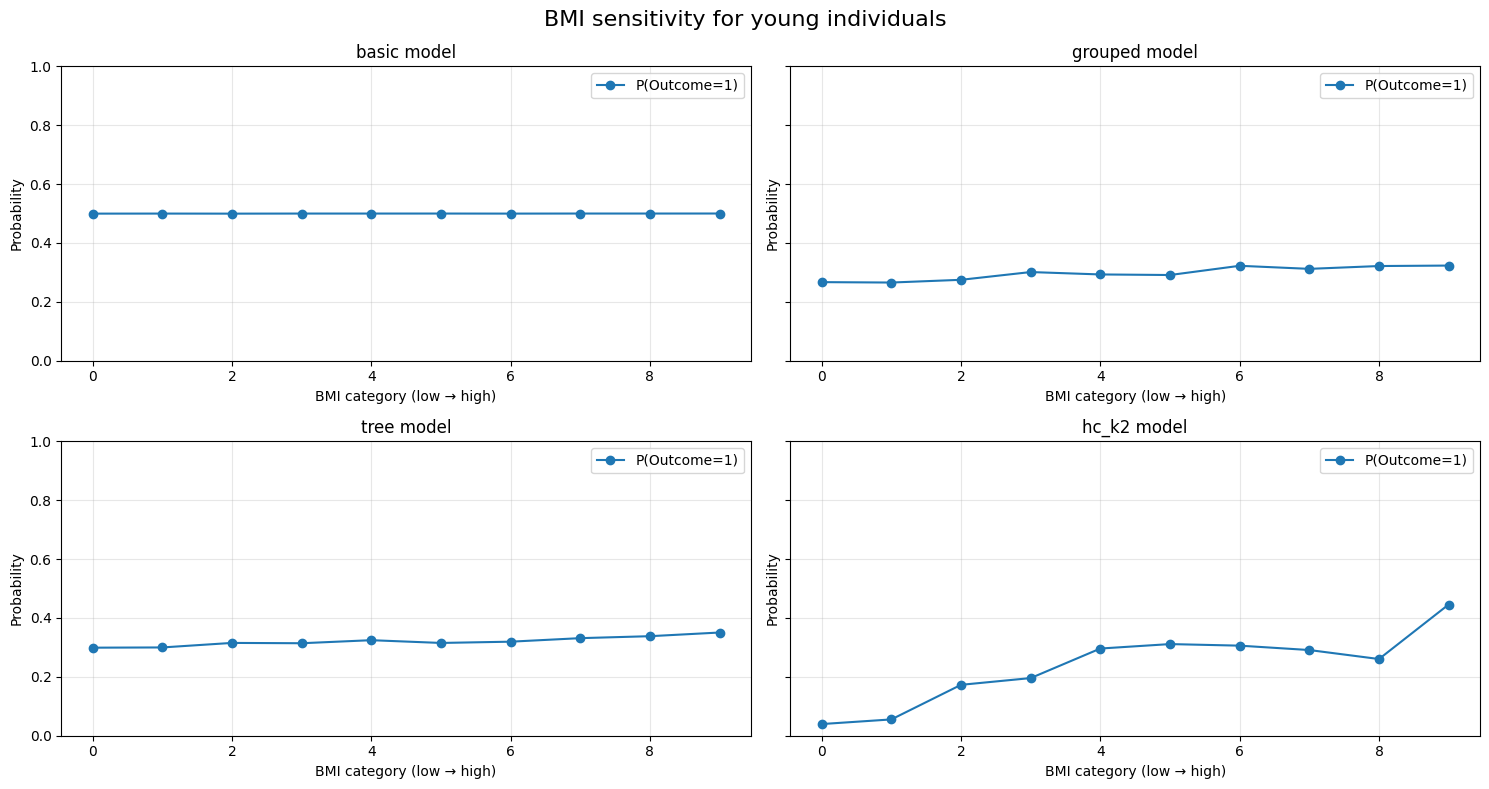


Change in P(Outcome=1) as BMI increases (Age fixed at young):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.1%)
grouped    | start=0.267, end=0.323, Δ=+0.056 (+21.1%)
tree       | start=0.299, end=0.351, Δ=+0.051 (+17.2%)
hc_k2      | start=0.040, end=0.446, Δ=+0.406 (+1025.0%)
hc_aic     | start=0.050, end=0.505, Δ=+0.455 (+915.4%)


In [ ]:
title = "BMI sensitivity for young individuals"
scores = [(2, b) for b in range(10)]  # Age = 2, BMI varies

answer_scores = {}
x_values = [b for _, b in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

plot_result(
    answer_scores,
    'question10_young.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at young"
)

#### Question 10b — Old group

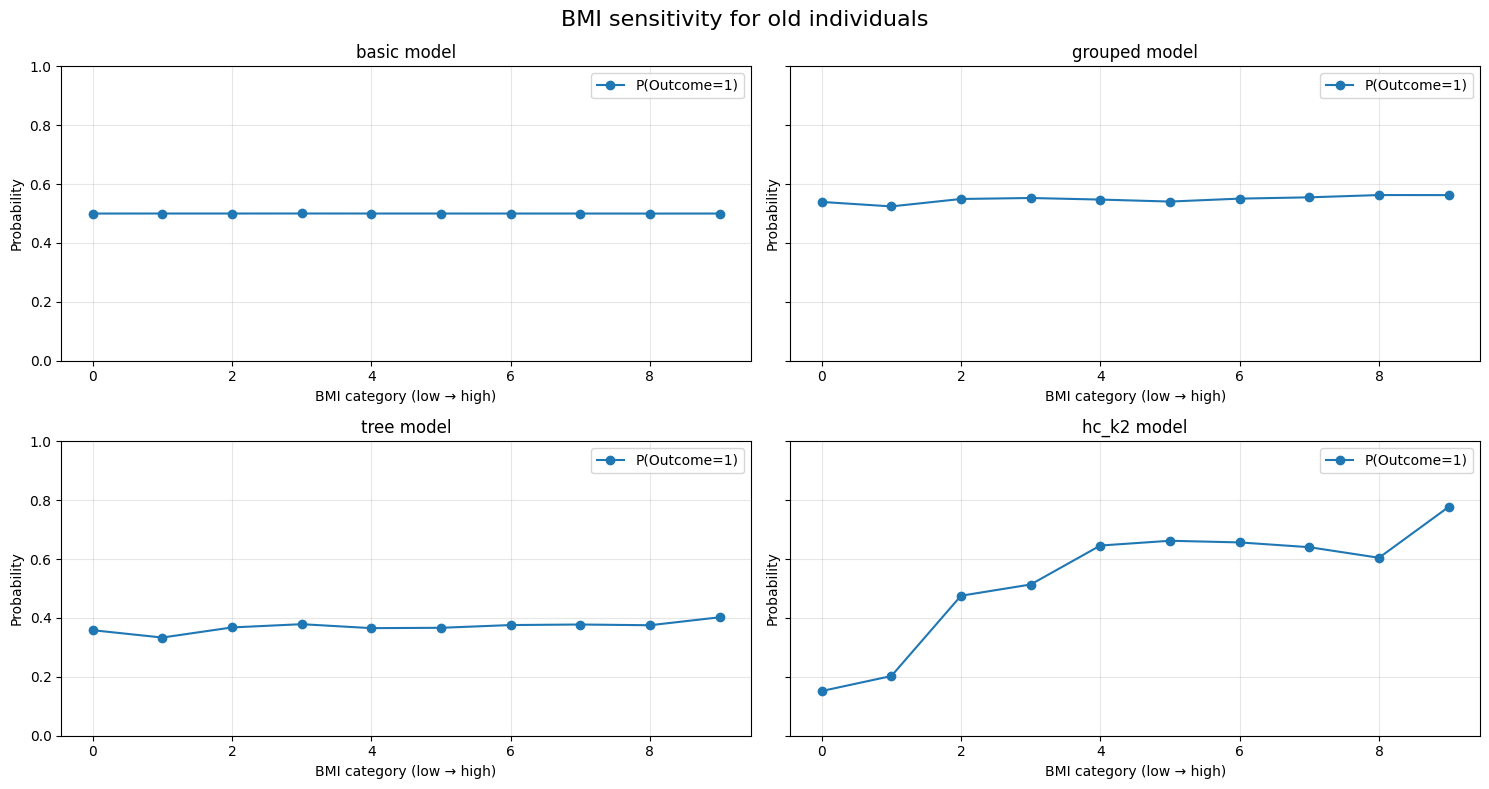


Change in P(Outcome=1) as BMI increases (Age fixed at old):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.539, end=0.563, Δ=+0.023 (+4.3%)
tree       | start=0.358, end=0.402, Δ=+0.044 (+12.2%)
hc_k2      | start=0.152, end=0.777, Δ=+0.625 (+412.0%)
hc_aic     | start=0.107, end=0.699, Δ=+0.593 (+556.3%)


In [ ]:
title = "BMI sensitivity for old individuals"
scores = [(8, b) for b in range(10)]  # Age = 8, BMI varies

answer_scores = {}
x_values = [b for _, b in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for age, bmi in scores:
        evidence = {"Age": age, "BMI": bmi}
        answer_scores[name][(age, bmi)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

plot_result(
    answer_scores,
    'question10_old.png',
    title,
    x_values,
    x_label="BMI category (low → high)"
)

print_outcome_change(
    answer_scores,
    variable_name="BMI",
    condition_note="Age fixed at old"
)

### Question 11 : Does diabetes risk increase with the number of pregnancies when genetic risk is high?

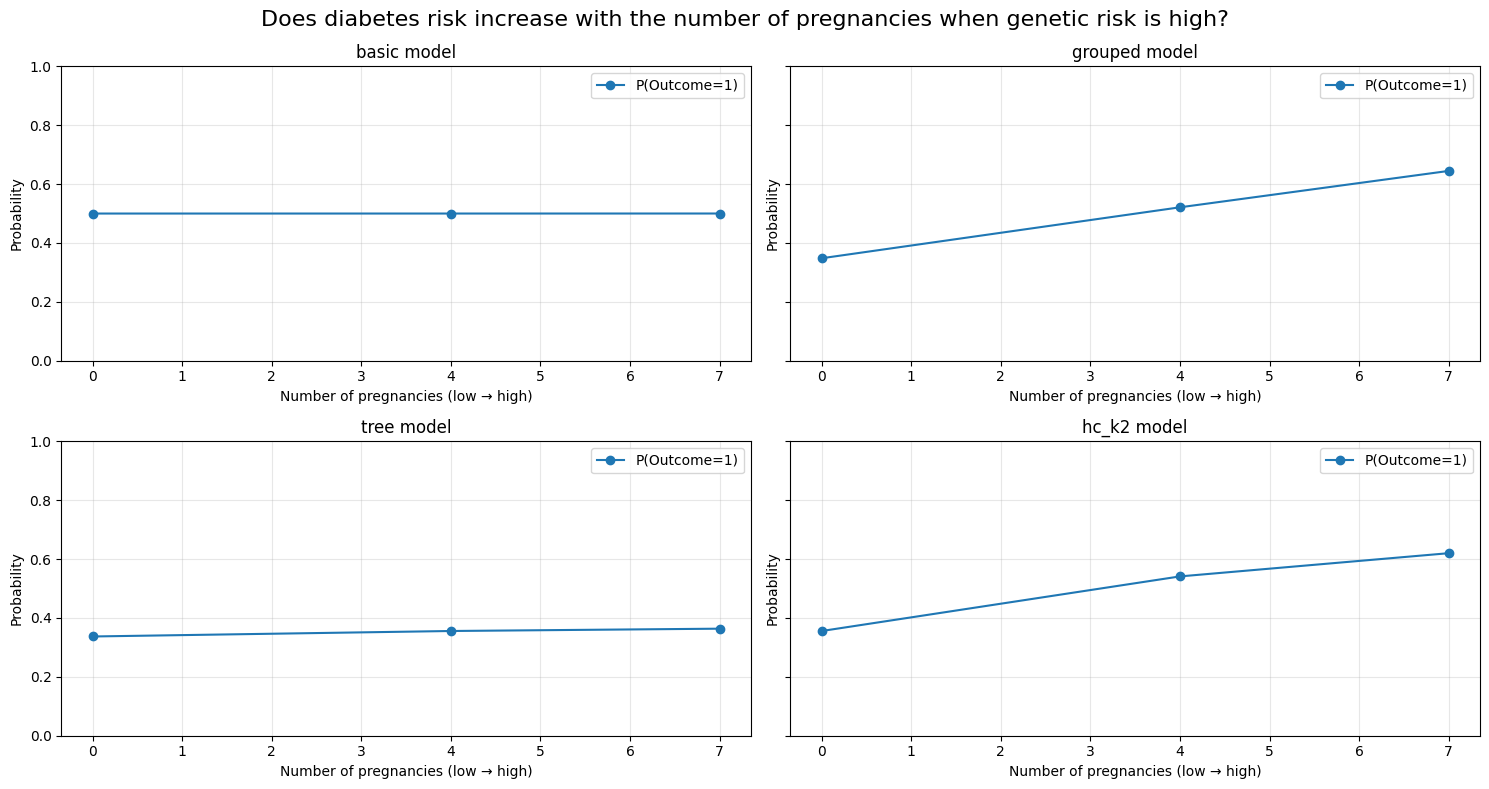


Change in P(Outcome=1) as Pregnancies increases (Genetic risk fixed high):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.348, end=0.645, Δ=+0.297 (+85.2%)
tree       | start=0.337, end=0.364, Δ=+0.027 (+7.9%)
hc_k2      | start=0.356, end=0.620, Δ=+0.264 (+74.3%)
hc_aic     | start=0.363, end=0.617, Δ=+0.255 (+70.1%)


In [ ]:
title = "Does diabetes risk increase with the number of pregnancies when genetic risk is high?"
scores = [(0, 8), (4, 8), (7, 8)]  # (Pregnancies, DiabetesPedigreeFunction)

answer_scores = {}
x_values = [preg for preg, _ in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for preg, dpf in scores:
        evidence = {
            "Pregnancies": preg,
            "DiabetesPedigreeFunction": dpf
        }
        answer_scores[name][(preg, dpf)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question11.png',
    title,
    x_values,
    x_label="Number of pregnancies (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Pregnancies",
    condition_note="Genetic risk fixed high"
)

### Question 12: Is genetic risk (DPF) alone sufficient to produce high diabetes probability?

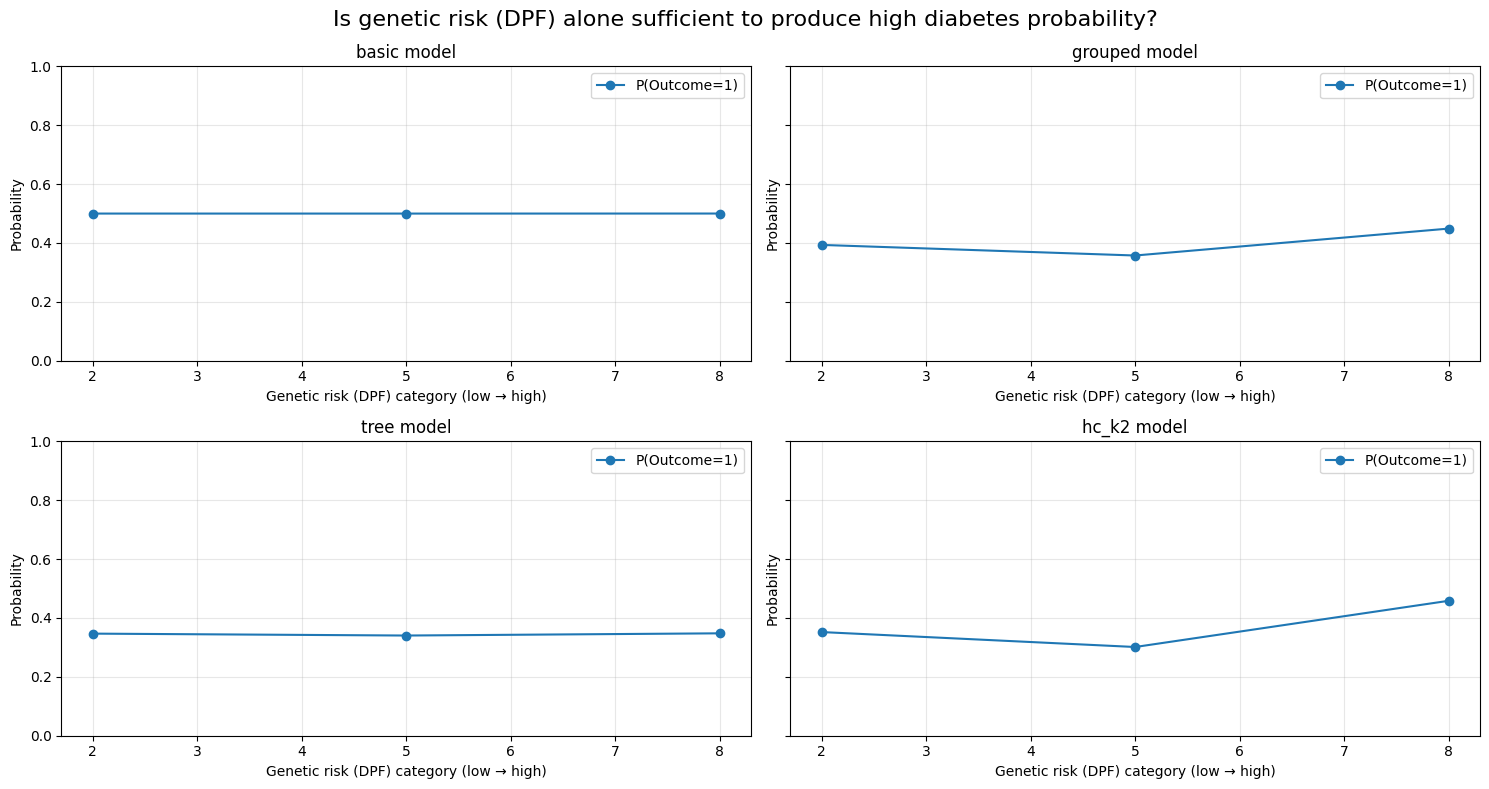


Change in P(Outcome=1) as Genetic risk (DPF) increases (DPF varies alone):

basic      | start=0.500, end=0.500, Δ=+0.000 (+0.0%)
grouped    | start=0.393, end=0.449, Δ=+0.055 (+14.1%)
tree       | start=0.347, end=0.348, Δ=+0.001 (+0.3%)
hc_k2      | start=0.352, end=0.458, Δ=+0.106 (+30.2%)
hc_aic     | start=0.352, end=0.458, Δ=+0.106 (+30.2%)


In [ ]:
title = "Is genetic risk (DPF) alone sufficient to produce high diabetes probability?"
scores = [(2,), (5,), (8,)]  # DiabetesPedigreeFunction varies

answer_scores = {}
x_values = [dpf for (dpf,) in scores]

for name, ve in inferences:
    answer_scores[name] = {}
    for (dpf,) in scores:
        evidence = {"DiabetesPedigreeFunction": dpf}
        answer_scores[name][(dpf,)] = ve.query(
            ["Outcome"], evidence, show_progress=False
        ).values

# ---- Plot ----
plot_result(
    answer_scores,
    'question12.png',
    title,
    x_values,
    x_label="Genetic risk (DPF) category (low → high)"
)

# ---- Summary ----
print_outcome_change(
    answer_scores,
    variable_name="Genetic risk (DPF)",
    condition_note="DPF varies alone"
)

## Total Results Comparison

In this study, we evaluated the impact of different preprocessing strategies and Bayesian Network structure learning methods on diabetes risk inference using the Indian Diabetes dataset.

Four preprocessing pipelines were considered:
- Mean Imputation + Quantile Discretization
- Mean Imputation + KMeans Discretization
- KNN Imputation + Quantile Discretization
- KNN Imputation + KMeans Discretization

For each preprocessing pipeline, five Bayesian Network structures were learned:
- Basic (fixed structure)
- Grouped
- Tree-based
- Hill Climbing with K2 score
- Hill Climbing with AIC score

This results in a total of **20 distinct models**, each evaluated across multiple clinically motivated inference questions.

---

### Initial Observation: Basic Models

Across all three glucose-related questions  the **basic models consistently produced identical probability distributions** regardless of the evidence provided. In all scenarios, the posterior probabilities of `Outcome=0` and `Outcome=1` remained approximately equal (≈ 0.5).

This behavior indicates that:
- The basic structures fail to encode meaningful conditional dependencies.
- Evidence provided to the model does not propagate effectively to the outcome node.

As a result, **basic models were excluded from further comparative analysis**, as they do not provide informative or discriminative inferences.

---

### PreProcessing Methods Comparison

After excluding the basic models, we compare the remaining preprocessing strategies based on the **average behavior across the three glucose-related questions**.

#### 1. Mean Imputation + Quantile Discretization

Models trained on mean-imputed and quantile-discretized data showed:
- Moderate sensitivity to changes in Age, BMI, and Glucose.
- Consistent trends across Grouped and Hill Climbing models.
- Relatively balanced uncertainty, as reflected by wider confidence intervals in several scenarios.

While this preprocessing strategy preserves global distributional properties, it appears to **smooth out extreme effects**, especially in high-risk glucose bins.

---

#### 2. Mean Imputation + KMeans Discretization

This preprocessing pipeline produced **sharper probability contrasts**, particularly in:
- Tree-based models
- Hill Climbing models with both K2 and AIC scores

In multiple scenarios, these models assigned **very high or very low diabetes probabilities**, suggesting that KMeans discretization captures localized structure in the feature space more effectively than quantile binning when paired with mean imputation.

However, some models exhibited overly confident predictions, which may indicate **overfitting to discretization-induced clusters**.

---

#### 3. KNN Imputation + Quantile Discretization

KNN-imputed datasets combined with quantile discretization demonstrated:
- More stable and consistent inference results across models
- Clear monotonic trends when Age or BMI increased under high Glucose conditions
- Reduced variance compared to mean-imputed counterparts

This suggests that KNN imputation better preserves multivariate relationships prior to discretization, allowing the Bayesian Networks to capture more realistic conditional dependencies.

---

#### 4. KNN Imputation + KMeans Discretization

Among all preprocessing strategies, **KNN Imputation + KMeans Discretization consistently produced the most interpretable and clinically plausible results**:

- High glucose combined with increasing age led to a clear increase in diabetes probability.
- High BMI amplified diabetes risk in younger individuals more distinctly than in other pipelines.
- Low BMI scenarios showed a noticeable protective effect even under high glucose conditions.

Hill Climbing models trained under this preprocessing pipeline demonstrated both **strong sensitivity to evidence** and **reasonable uncertainty**, making them particularly suitable for scenario-based risk analysis.

---

### Model Structure Comparison (Non-Basic Models)

Across all preprocessing pipelines, the following general trends were observed:

- **Grouped models** produced conservative and stable estimates, often serving as a baseline among non-basic structures.
- **Tree-based models** were highly sensitive to evidence but occasionally produced extreme probabilities.
- **Hill Climbing models (K2 and AIC)** provided the most expressive structures, with K2 favoring stronger dependencies and AIC yielding slightly more regularized graphs.

Notably, Hill Climbing models benefited the most from KNN-based imputation, indicating that structure learning is highly sensitive to the quality of missing-value handling.

---

### Summary of Key Findings

- Basic Bayesian Network structures are insufficient for meaningful inference and should be avoided.
- Preprocessing choice has a **substantial impact** on downstream probabilistic inference.
- KNN imputation consistently outperforms mean imputation in preserving conditional relationships.
- KMeans discretization enhances model sensitivity but should be paired with robust imputation.
- Hill Climbing–based Bayesian Networks, particularly with KNN + KMeans preprocessing, provide the most reliable and interpretable results.

Overall, the results highlight that **Bayesian Network inference quality is driven more by preprocessing decisions than by the choice of scoring function alone**, underscoring the importance of careful data preparation in probabilistic modeling.

## TODO

- classification report
- 